# Classification label distributions

In [18]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Collect ground-truth CSVs from train/val/test
base_dir = Path("/Volumes/T7/largeProject_copy/dataset/classification")
csv_paths = sorted(base_dir.glob("*/ground_truth/*.csv"))

if not csv_paths:
    raise FileNotFoundError(
        f"No ground-truth CSVs found under {base_dir}. Expected */ground_truth/*.csv"
    )

dfs = [pd.read_csv(p) for p in csv_paths]
all_gt = pd.concat(dfs, ignore_index=True)

# Heuristic to find label columns
single_label_cols = [
    c
    for c in all_gt.columns
    if c.lower() in {"label", "labels", "diagnosis", "dx", "target", "class"}
]

if single_label_cols:
    label_col = single_label_cols[0]
    label_counts = all_gt[label_col].value_counts().sort_index()
    plot_df = label_counts.reset_index()
    plot_df.columns = ["label", "count"]
else:
    exclude = {
        c
        for c in all_gt.columns
        if any(
            token in c.lower()
            for token in ["image", "id", "filename", "file", "name", "lesion"]
        )
    }
    numeric_cols = [
        c
        for c in all_gt.columns
        if c not in exclude and pd.api.types.is_numeric_dtype(all_gt[c])
    ]

    if numeric_cols:
        label_counts = all_gt[numeric_cols].sum().sort_values(ascending=False)
        plot_df = label_counts.reset_index()
        plot_df.columns = ["label", "count"]
    else:
        # Fallback: use the last column
        label_col = all_gt.columns[-1]
        label_counts = all_gt[label_col].value_counts().sort_index()
        plot_df = label_counts.reset_index()
        plot_df.columns = ["label", "count"]

plt.figure(figsize=(10, 5))
sns.barplot(data=plot_df, x="label", y="count", color="#4C72B0")
plt.title("Classification label distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


FileNotFoundError: No ground-truth CSVs found under /Volumes/T7/largeProject_copy/dataset/classification. Expected */ground_truth/*.csv

In [22]:
resnet_perf = {"accuracy": 0.8439, "sensitivity": 0.735, "specificity": 0.96, "parameters": "23.52M", "inference_time": "10.049ms"}
densenet121_perf = {"accuracy": 0.8241, "sensitivity": 0.6698, "specificity": 0.9523, "parameters": "6.96M", "inference_time": "16.939ms"}
densenet50_perf = {"accuracy": 0.7189, "sensitivity": 0.4494, "specificity": 0.9284, "parameters": "3.64M", "inference_time": "11.362ms"}
classification_models = ["ResNet", "DenseNet121", "DenseNet50"]

deeplabv3_perf = {"dice": 0.8845, "mean_iou": 0.7963, "pixel_accuracy": 0.9335, "parameters": "41.99M", "inference_time": "64.565ms"}
multitask = {"accuracy": 0.8264, "sensitivity": 0.6434, "specificity": 0.9472, "dice": 0.9202, "mean_iou": 0.8647, "pixel_accuracy": 0.9551, "parameters": "32.350M", "inference_time": "21.24ms"}
multitask_mixed = {"accuracy": 0.7935, "sensitivity": 0.5815, "specificity": 0.9425, "dice": 0.8547, "mean_iou": 0.7743, "pixel_accuracy": 0.9178, "parameters": "32.350M", "inference_time": "21.24ms"}
multitask_partial = {"accuracy": 0.7844, "sensitivity": 0.6857, "specificity": 0.9523, "dice": 0.8690, "mean_iou": 0.7891, "pixel_accuracy": 0.9250, "parameters": "32.350M", "inference_time": "21.24ms"}



TABLE 1: Comprehensive Model Performance Comparison
              Model           Task Accuracy (%) Sensitivity (%) Specificity (%) Dice (%) IoU (%) Pixel Acc (%)  Params (M)  Inference (ms)
          ResNet-50 Classification        84.39            73.5            96.0        —       —             —       23.52           10.05
       DenseNet-121 Classification        82.41           66.98           95.23        —       —             —        6.96           16.94
        DenseNet-50 Classification        71.89           44.94           92.84        —       —             —        3.64           11.36
 DeepLabV3+ResNet50   Segmentation            —               —               —    88.45   79.63         93.35       41.99           64.57
   MultiTask (Full)           Both        82.64           64.34           94.72    92.02   86.47         95.51       32.35           21.24
  MultiTask (Mixed)           Both        79.35           58.15           94.25    85.47   77.43         91.78    

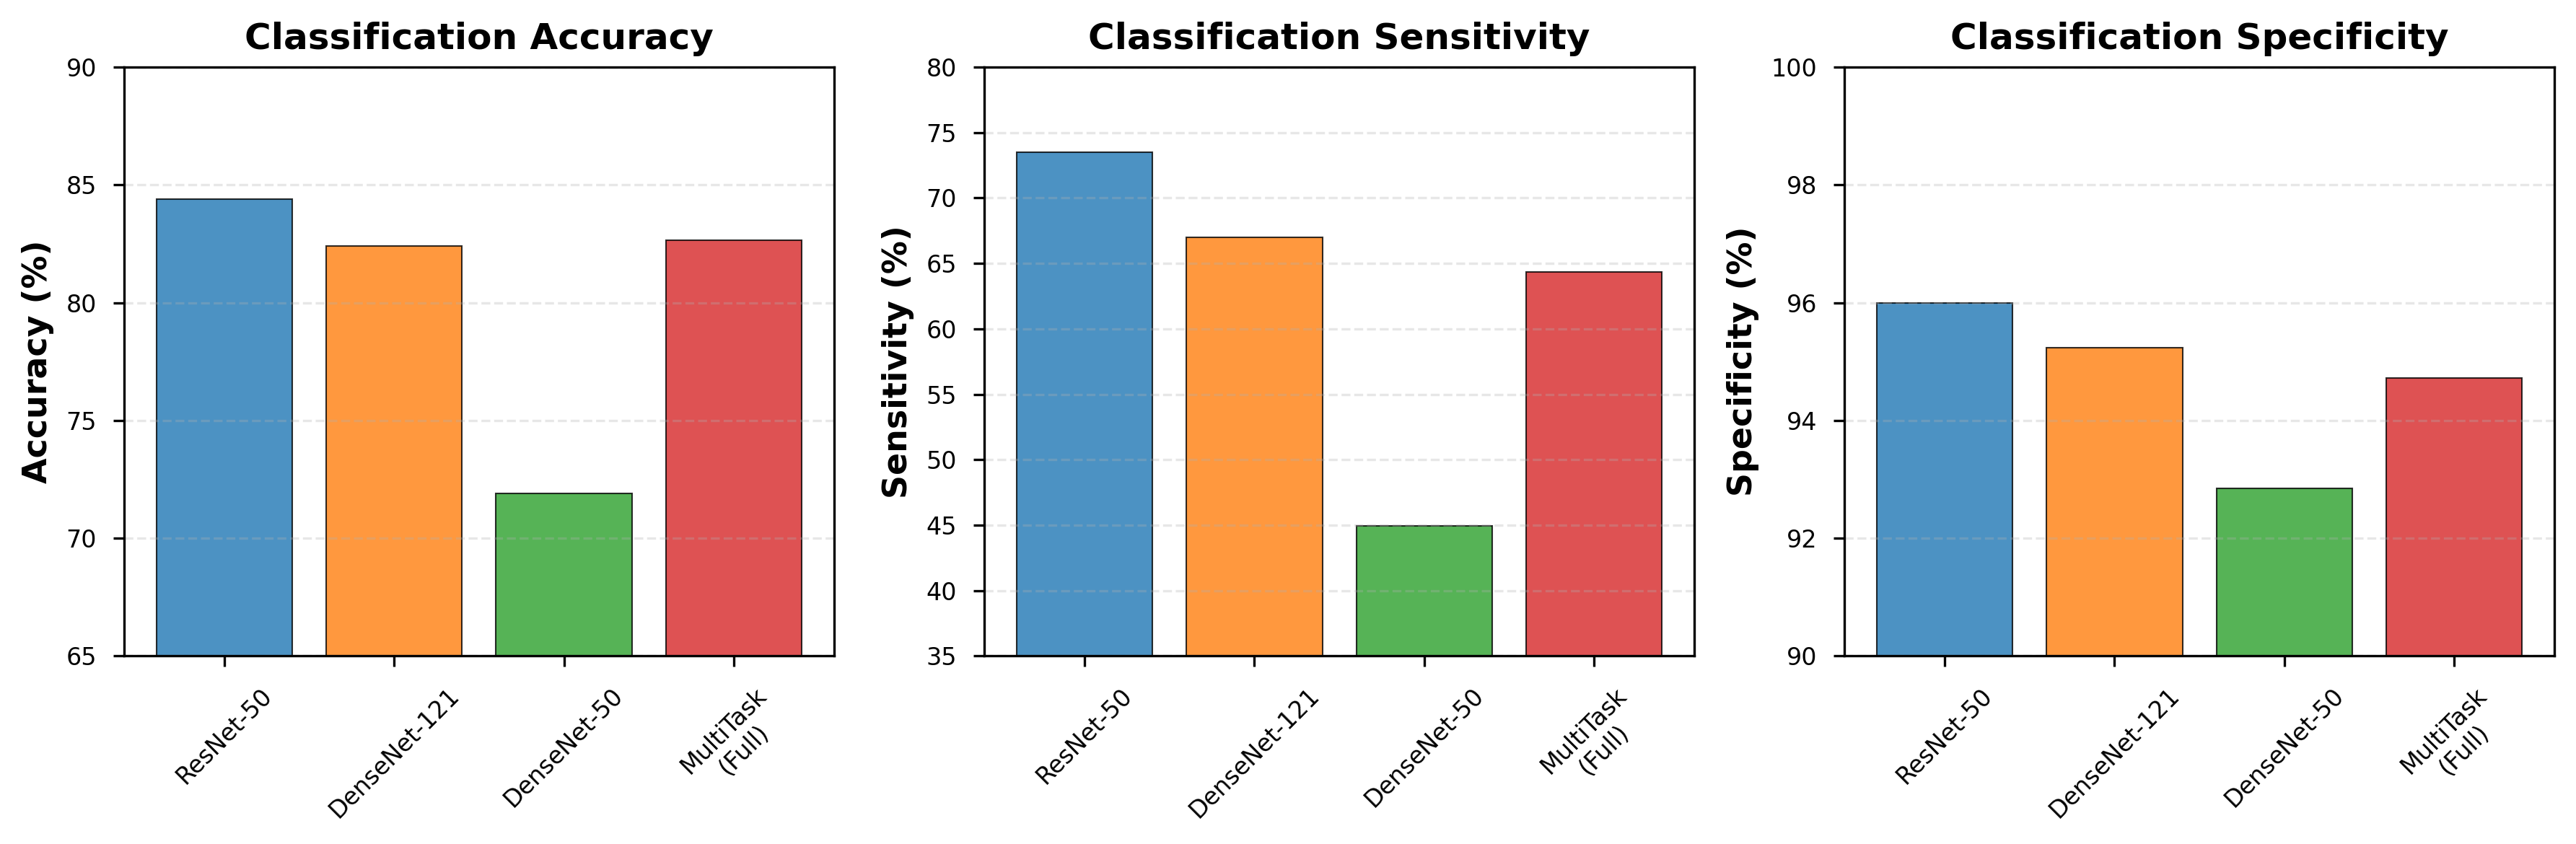

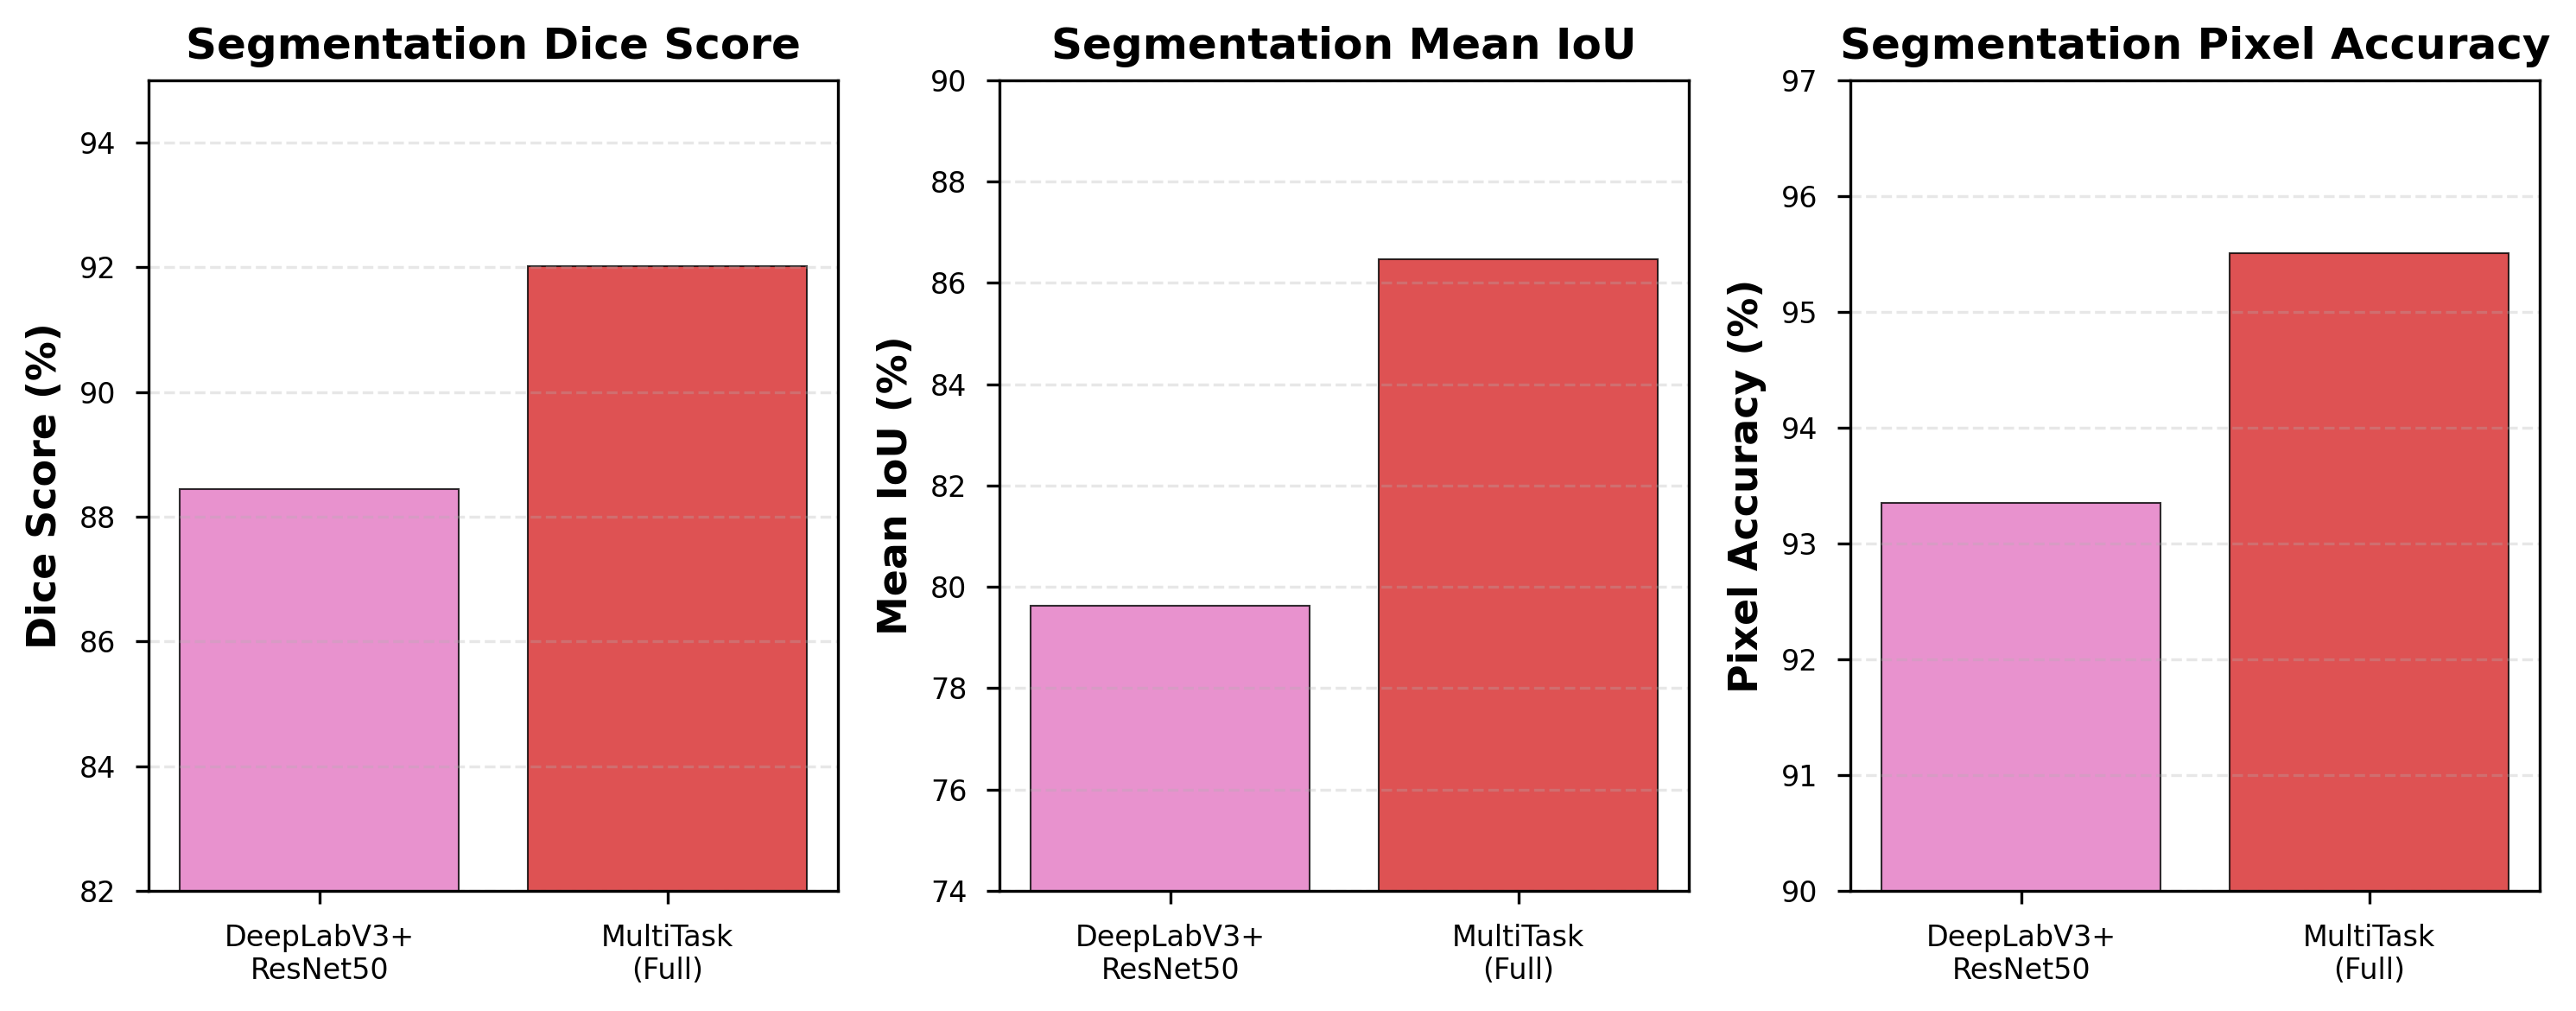

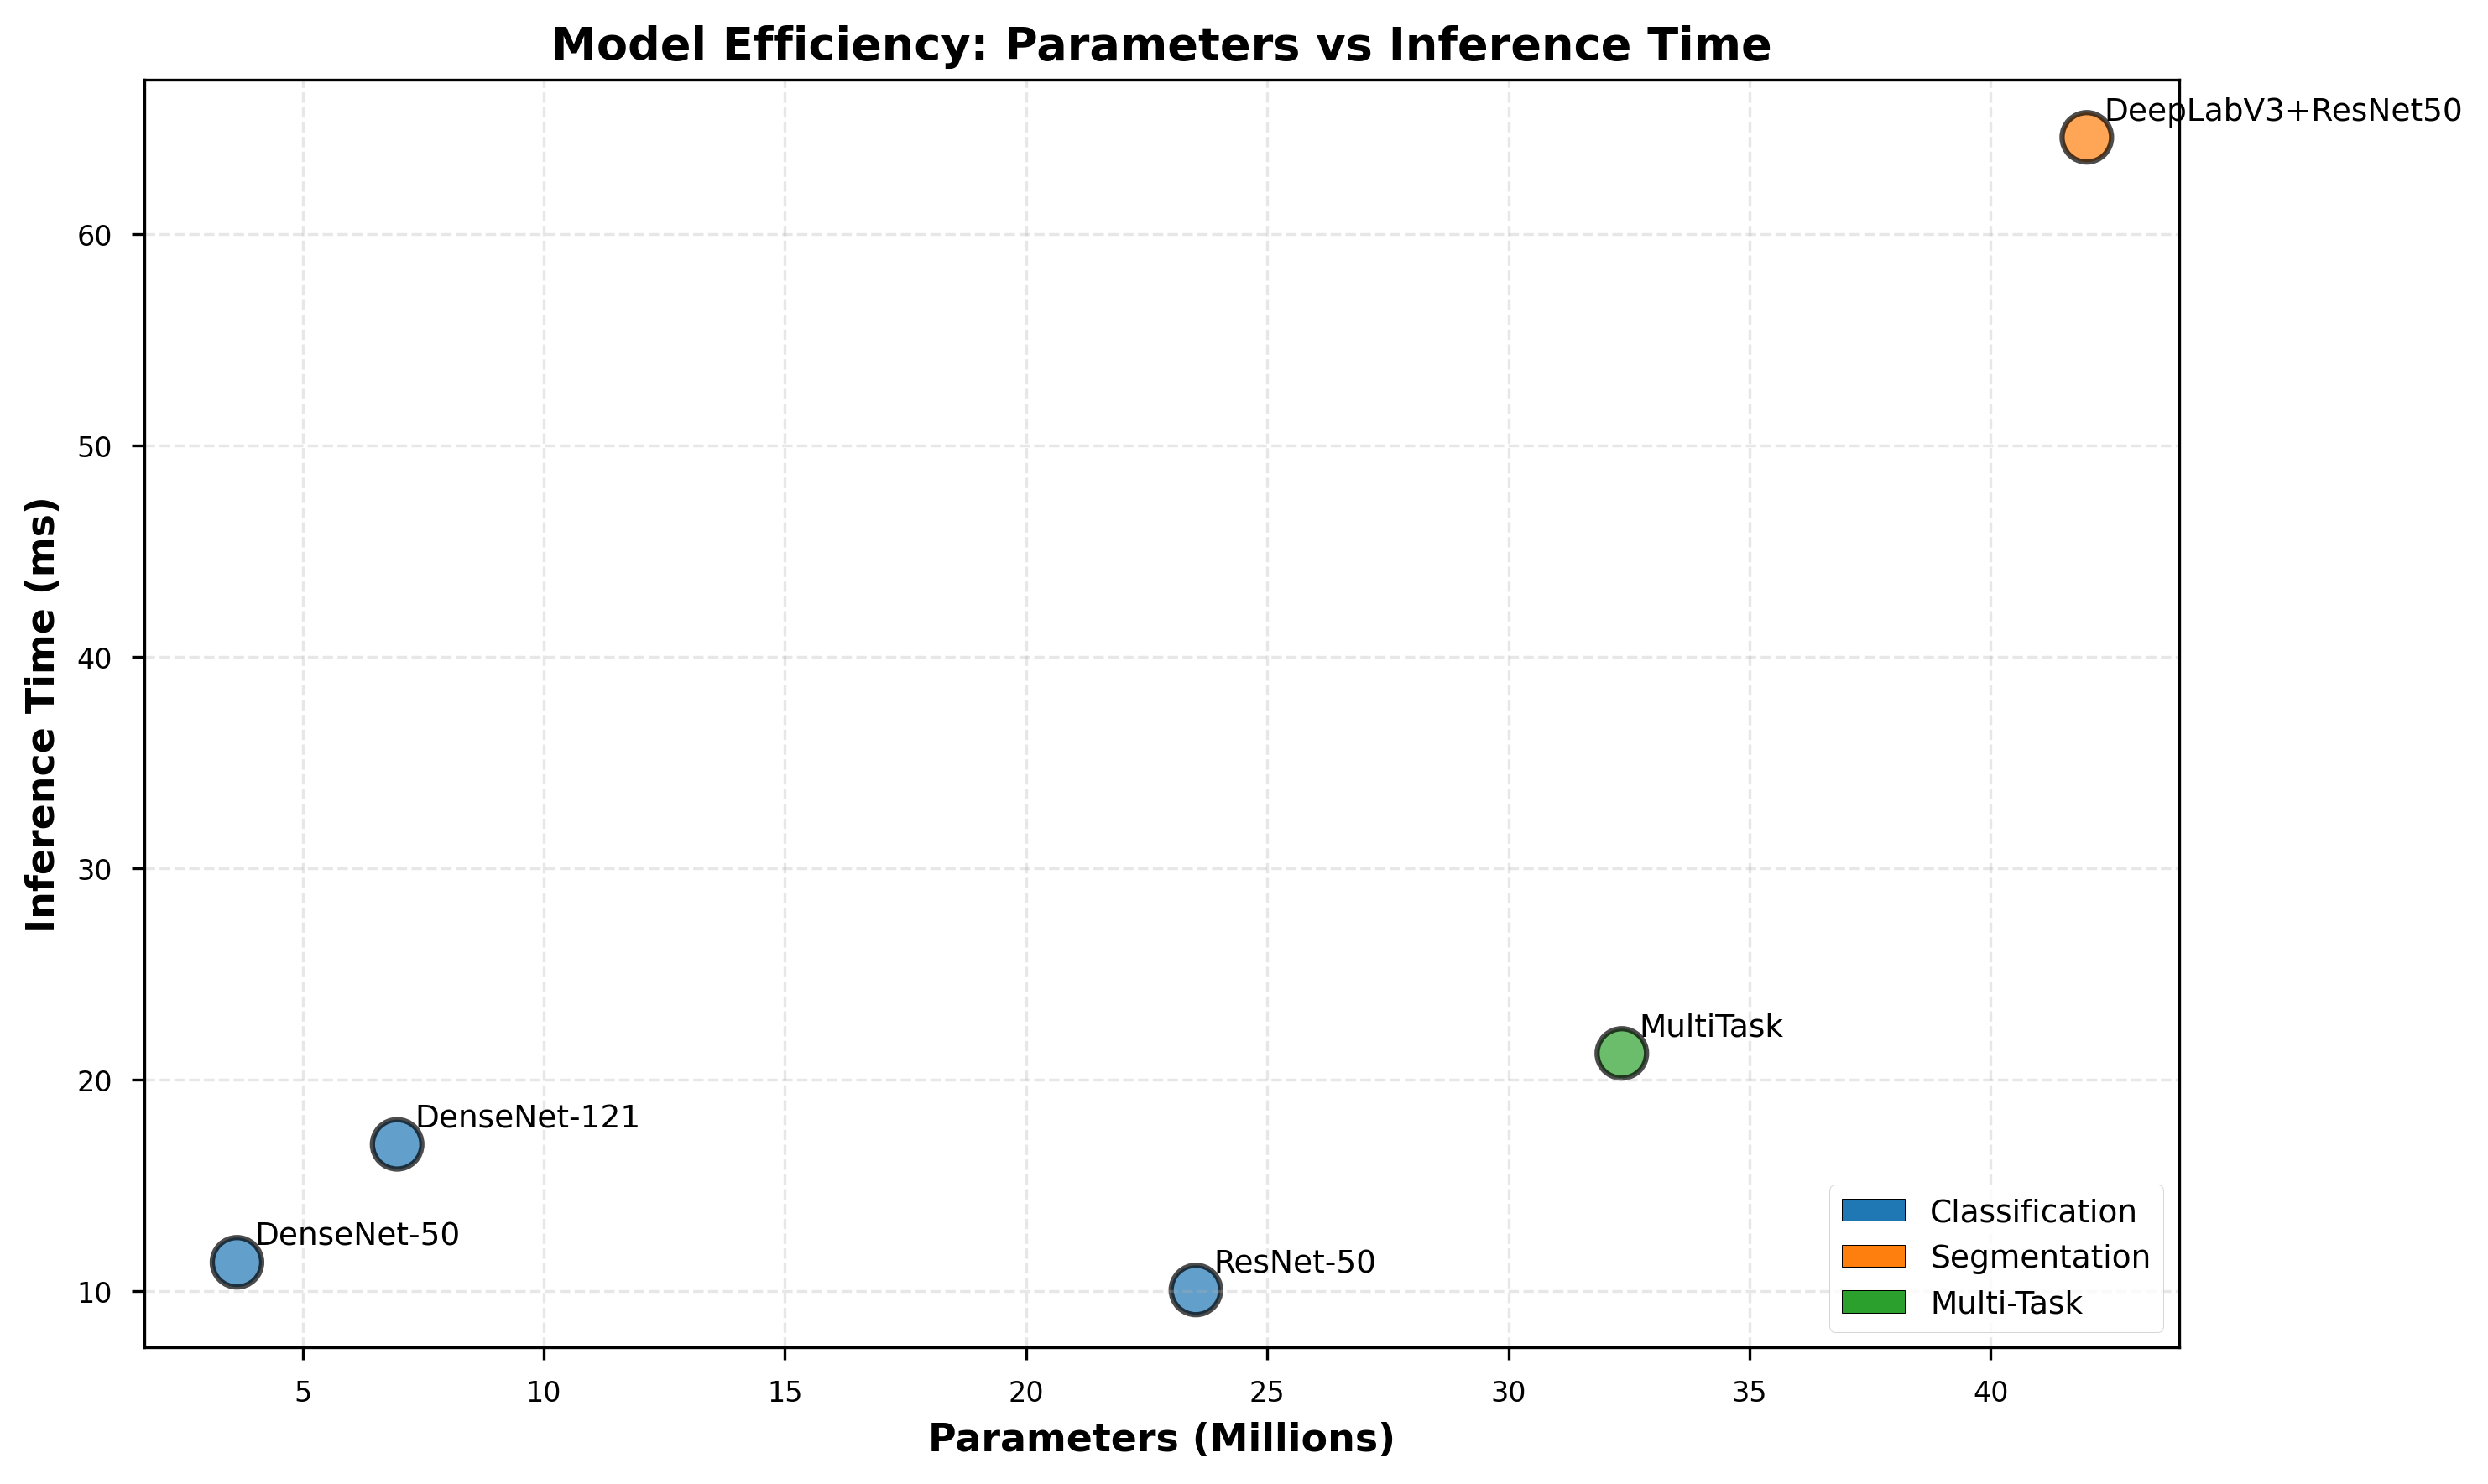

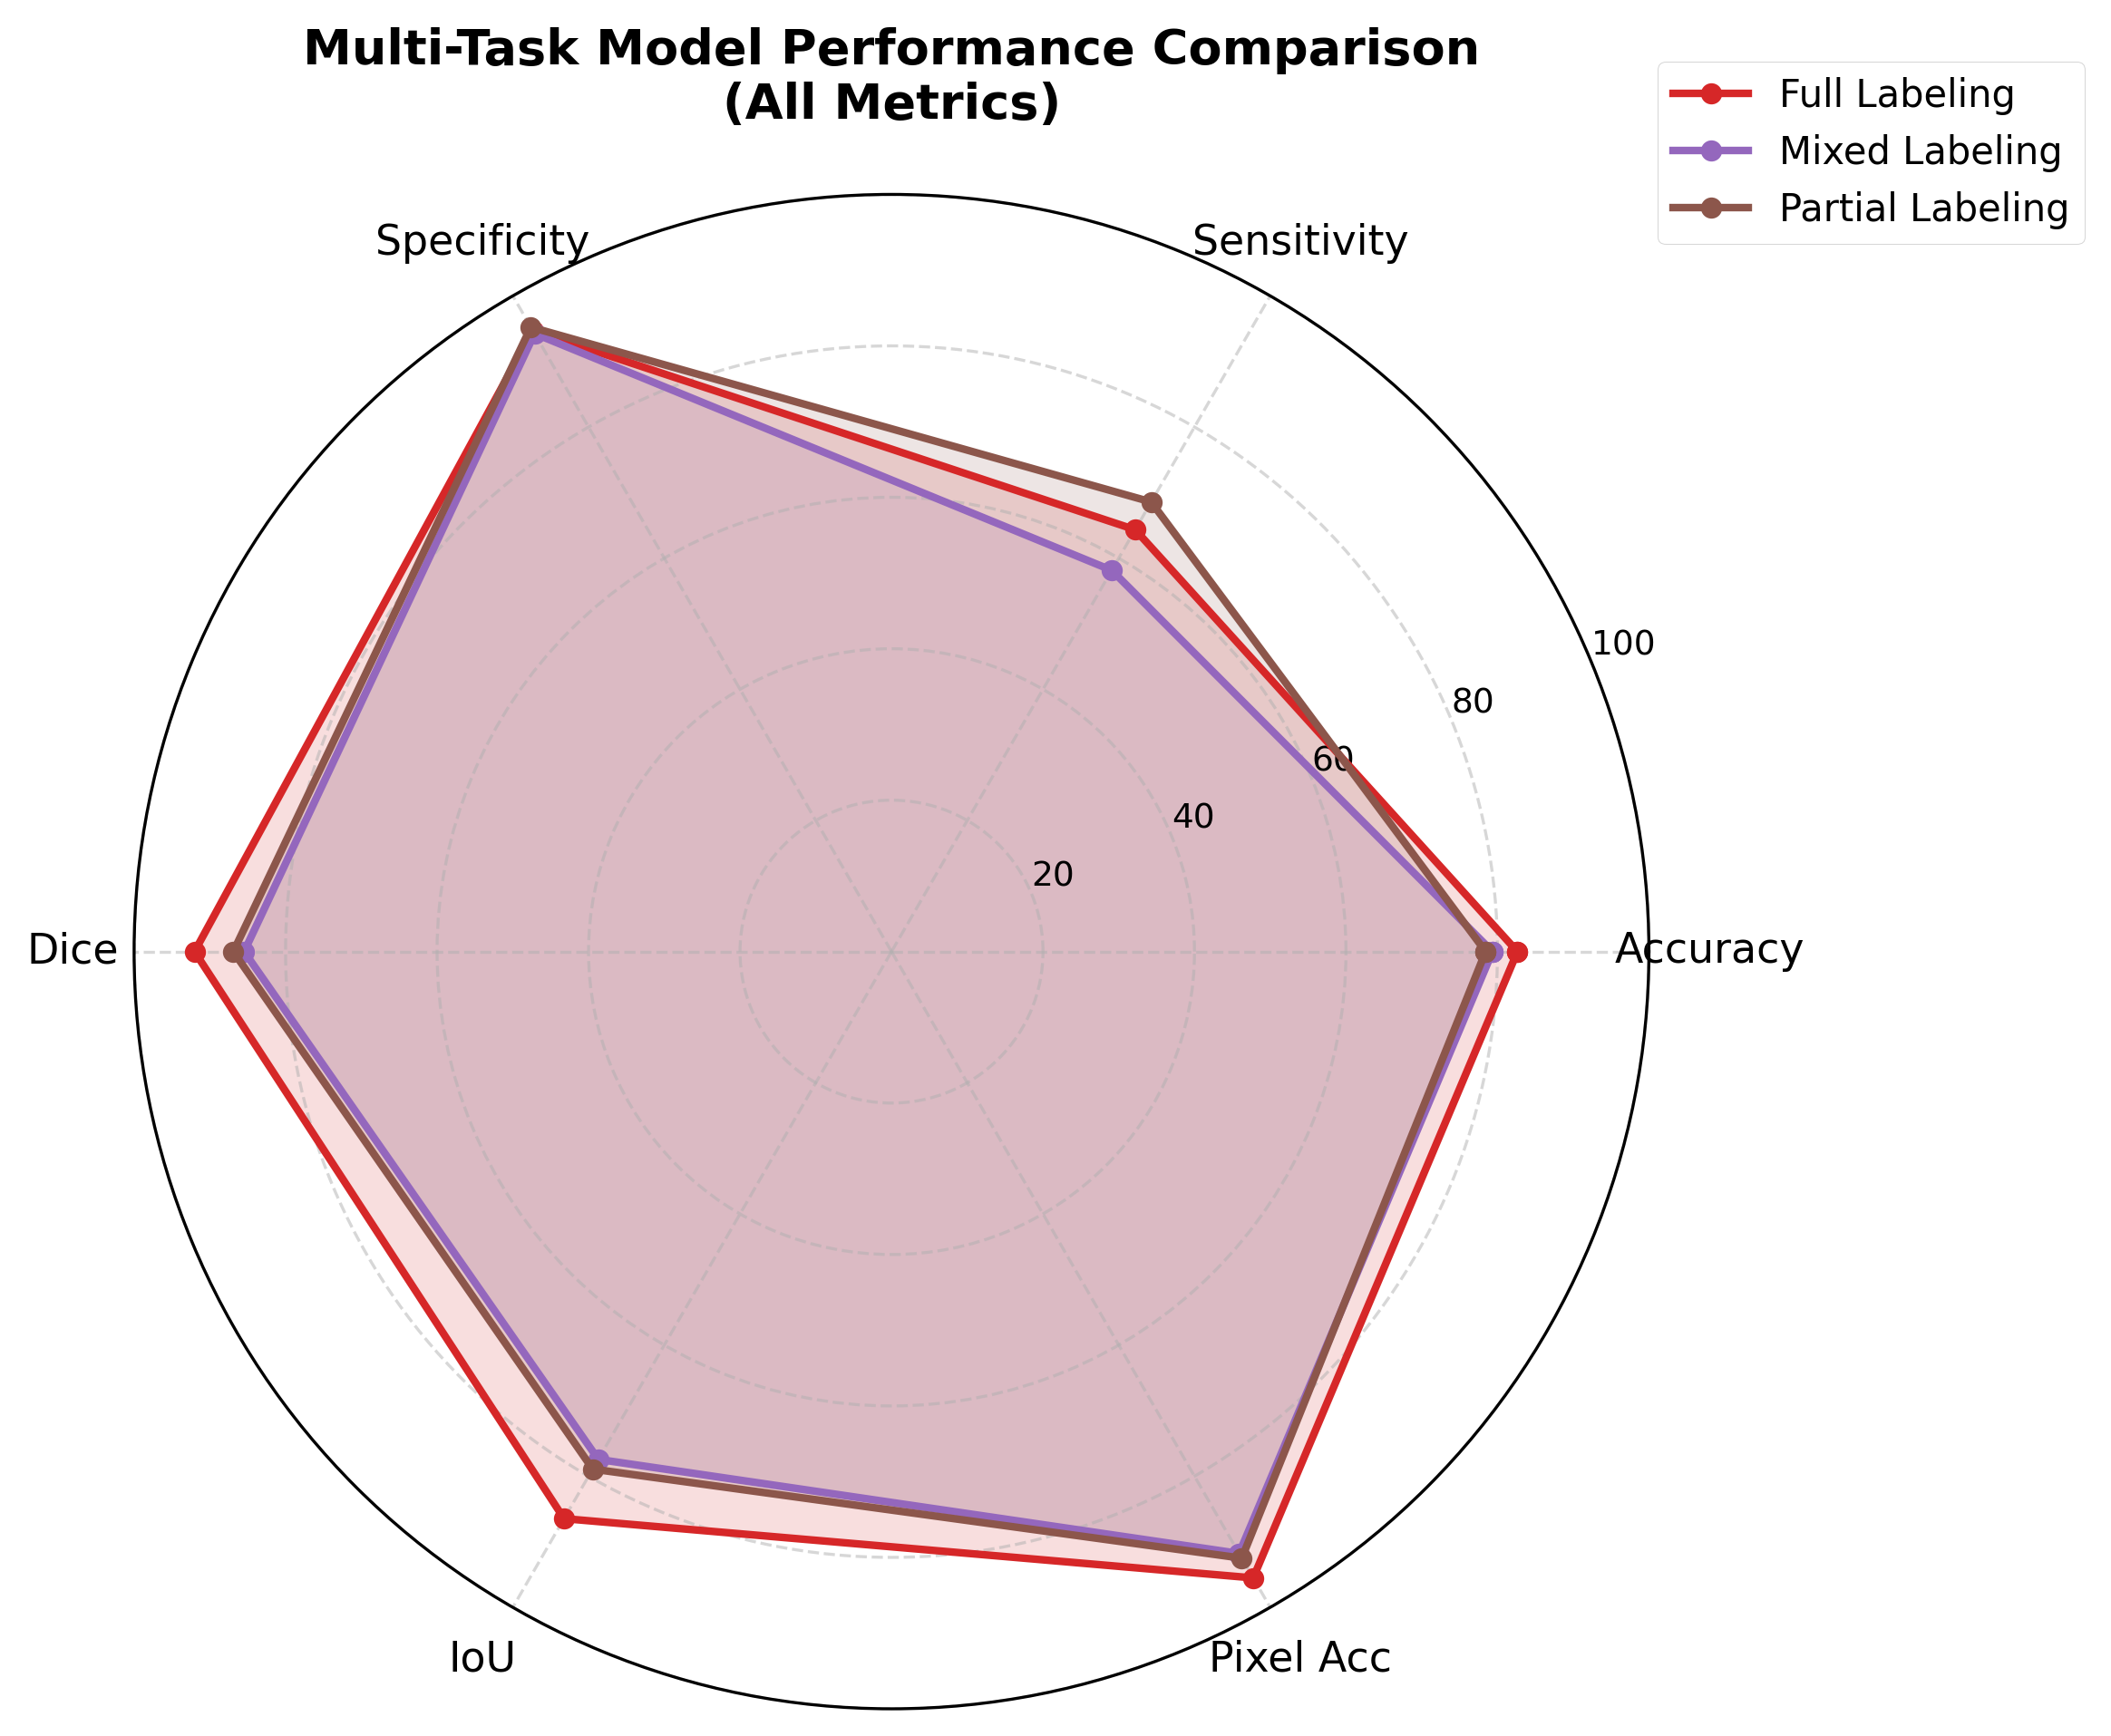

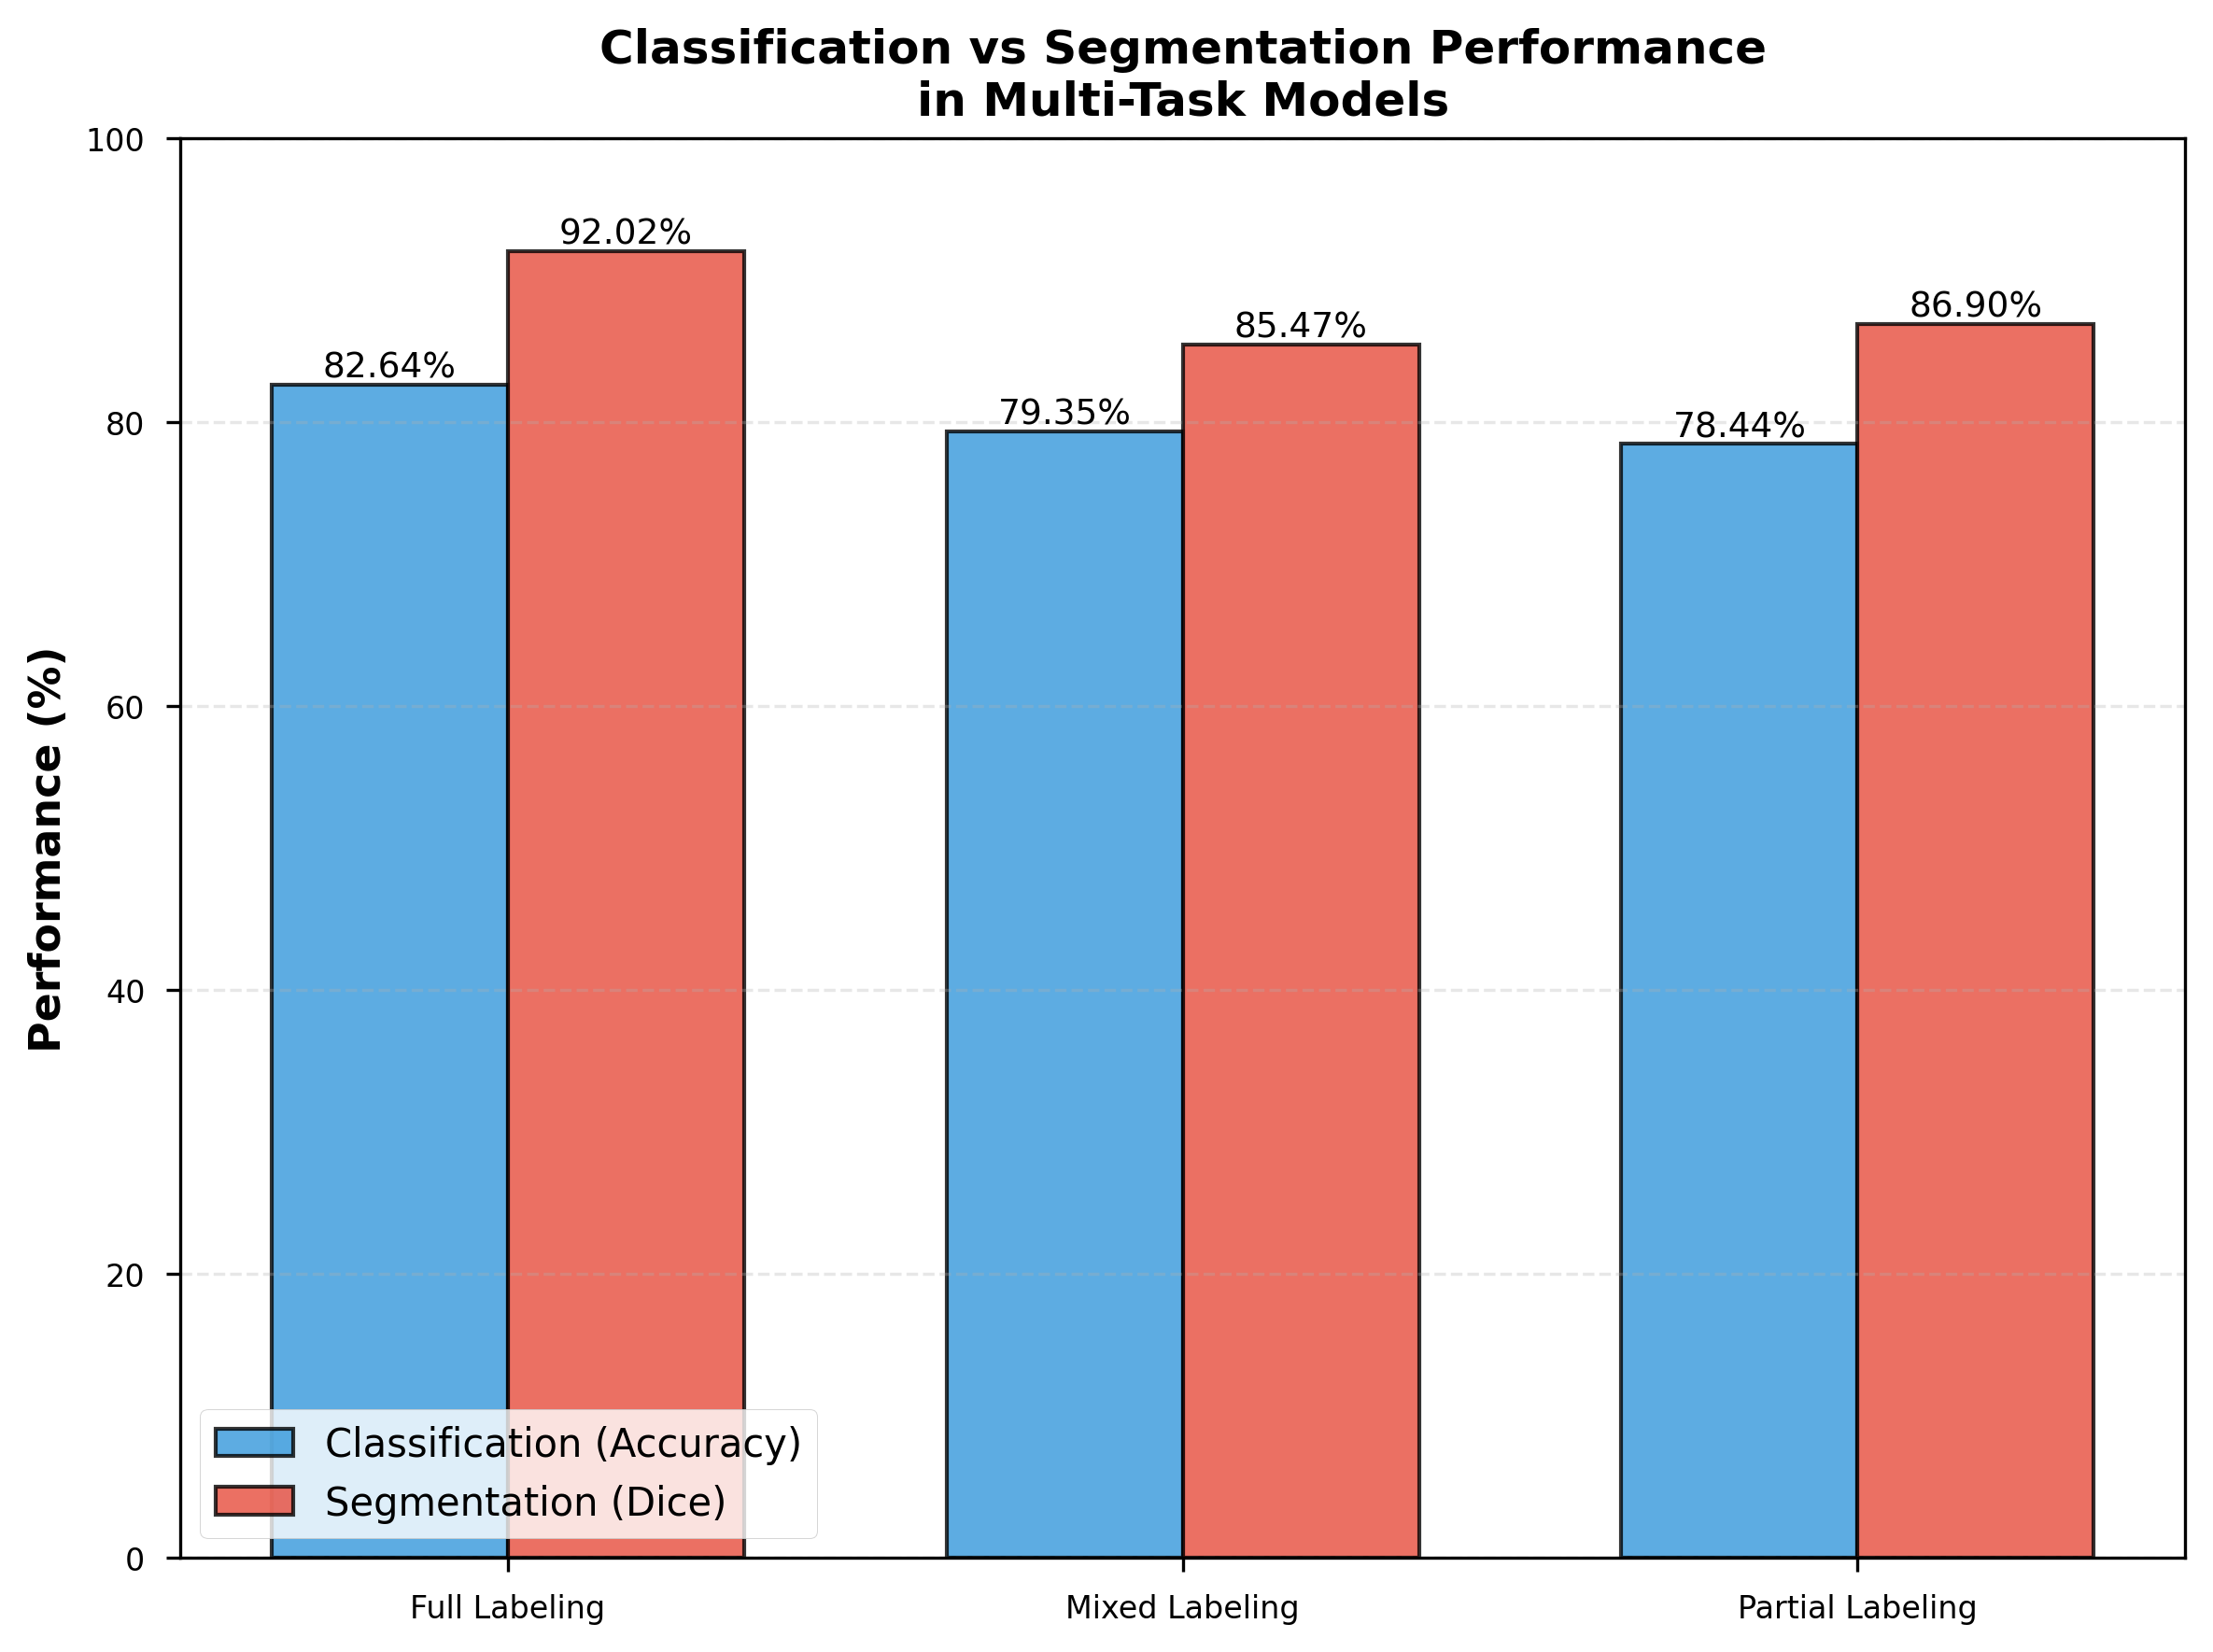

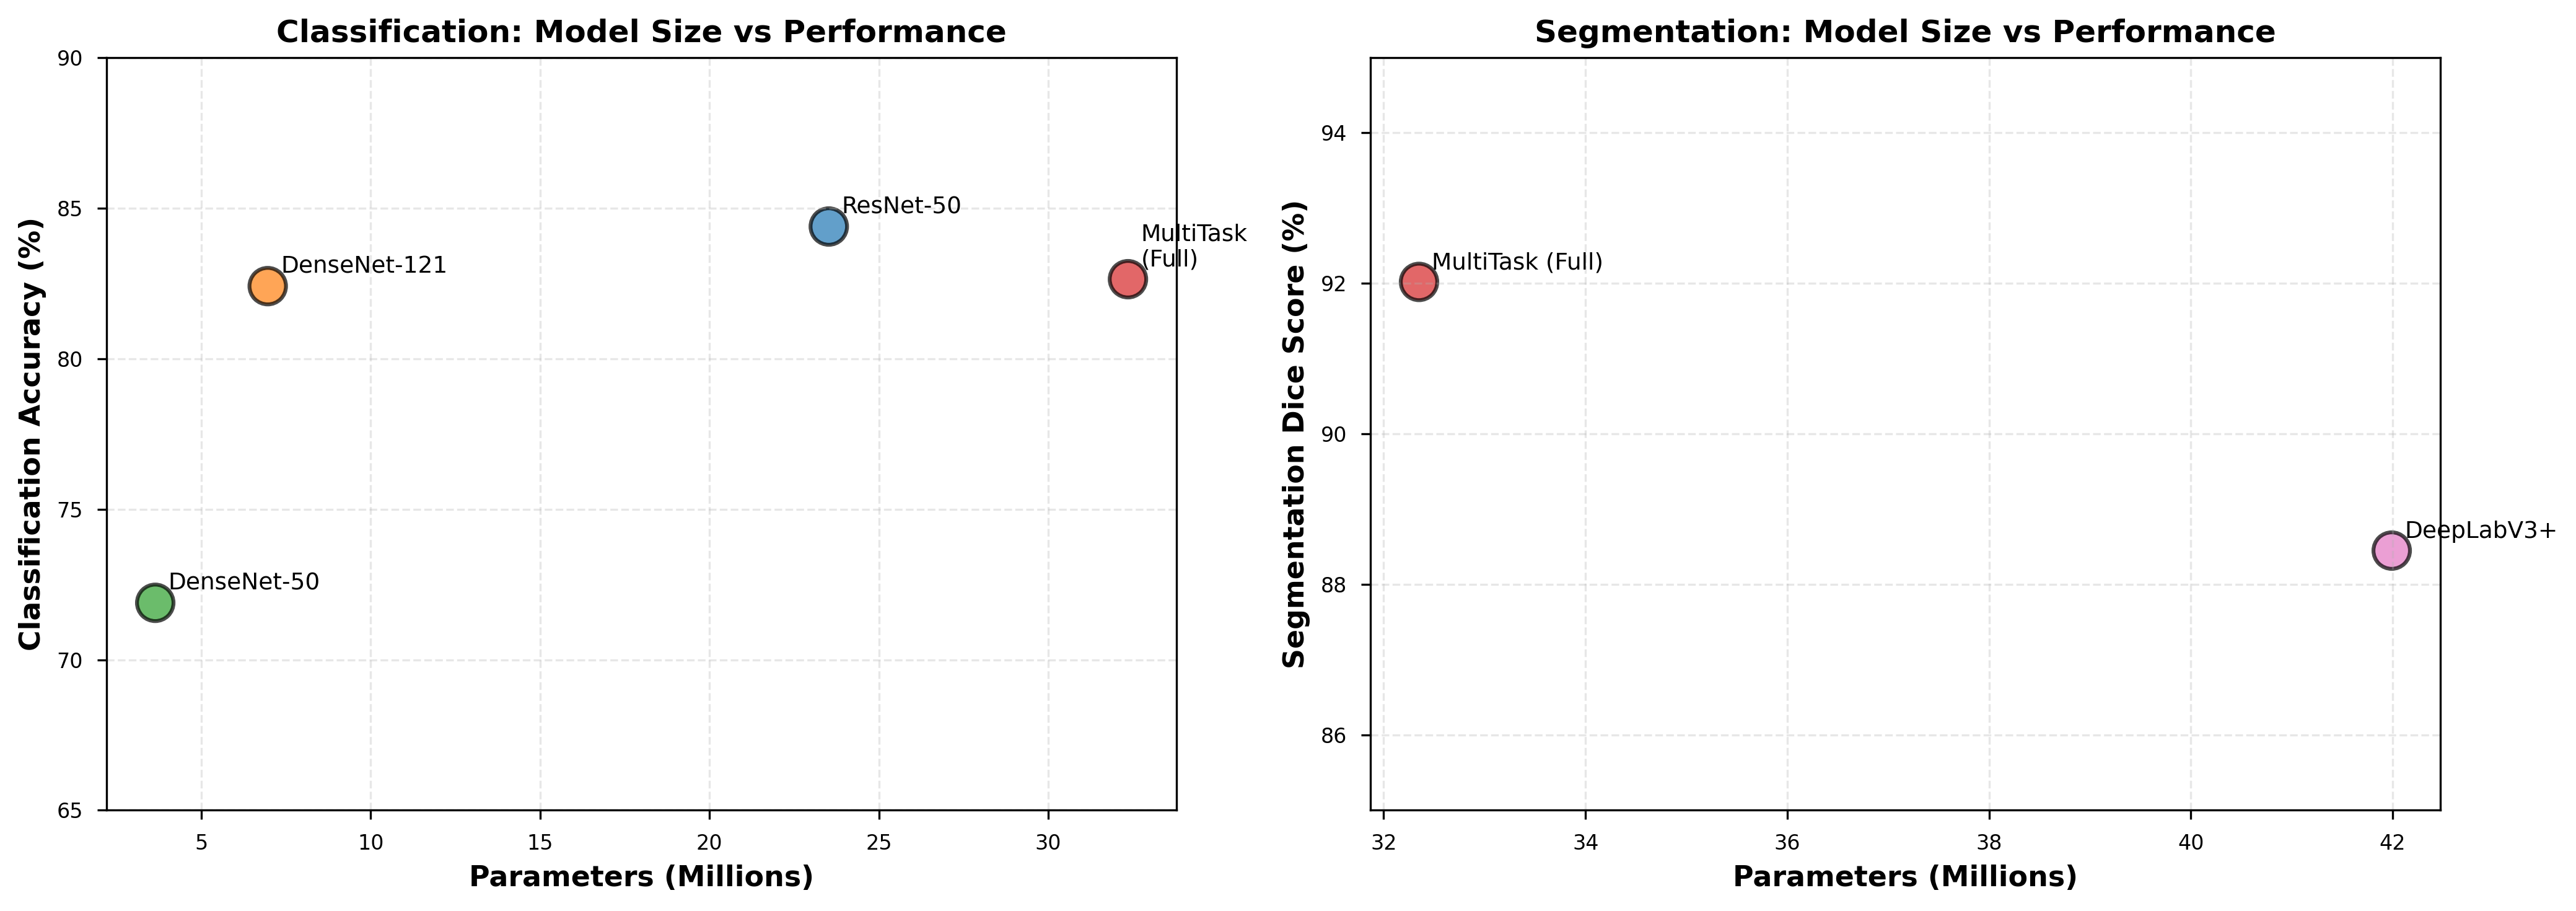


All visualizations and tables generated successfully!
Saved files:
  - classification_metrics_comparison.png
  - segmentation_metrics_comparison.png
  - efficiency_comparison.png
  - multitask_radar_comparison.png
  - classification_vs_segmentation_tradeoff.png
  - complexity_vs_performance.png


In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle

# Set publication-quality style
plt.style.use('seaborn-v0_8-paper')
sns.set_palette("husl")
plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['legend.fontsize'] = 9

# ============================================================================
# TABLE 1: Model Performance Comparison
# ============================================================================
print("=" * 80)
print("TABLE 1: Comprehensive Model Performance Comparison")
print("=" * 80)

# Create comprehensive comparison table
comparison_data = {
    'Model': ['ResNet-50', 'DenseNet-121', 'DenseNet-50', 'DeepLabV3+ResNet50', 
              'MultiTask (Full)', 'MultiTask (Mixed)', 'MultiTask (Partial)'],
    'Task': ['Classification', 'Classification', 'Classification', 'Segmentation',
             'Both', 'Both', 'Both'],
    'Accuracy (%)': [84.39, 82.41, 71.89, '—', 82.64, 79.35, 78.44],
    'Sensitivity (%)': [73.50, 66.98, 44.94, '—', 64.34, 58.15, 68.57],
    'Specificity (%)': [96.00, 95.23, 92.84, '—', 94.72, 94.25, 95.23],
    'Dice (%)': ['—', '—', '—', 88.45, 92.02, 85.47, 86.90],
    'IoU (%)': ['—', '—', '—', 79.63, 86.47, 77.43, 78.91],
    'Pixel Acc (%)': ['—', '—', '—', 93.35, 95.51, 91.78, 92.50],
    'Params (M)': [23.52, 6.96, 3.64, 41.99, 32.35, 32.35, 32.35],
    'Inference (ms)': [10.05, 16.94, 11.36, 64.57, 21.24, 21.24, 21.24]
}

df_comparison = pd.DataFrame(comparison_data)
print(df_comparison.to_string(index=False))
print("\n")

# ============================================================================
# TABLE 2: Classification Performance Summary
# ============================================================================
print("=" * 80)
print("TABLE 2: Classification Models Performance")
print("=" * 80)

cls_data = {
    'Model': ['ResNet-50', 'DenseNet-121', 'DenseNet-50', 'MultiTask (Full)', 
              'MultiTask (Mixed)', 'MultiTask (Partial)'],
    'Accuracy': [84.39, 82.41, 71.89, 82.64, 79.35, 78.44],
    'Sensitivity': [73.50, 66.98, 44.94, 64.34, 58.15, 68.57],
    'Specificity': [96.00, 95.23, 92.84, 94.72, 94.25, 95.23],
    'Parameters (M)': [23.52, 6.96, 3.64, 32.35, 32.35, 32.35],
    'Inference (ms)': [10.05, 16.94, 11.36, 21.24, 21.24, 21.24]
}

df_cls = pd.DataFrame(cls_data)
print(df_cls.to_string(index=False))
print("\n")

# ============================================================================
# TABLE 3: Multi-Task Models - Full Performance
# ============================================================================
print("=" * 80)
print("TABLE 3: Multi-Task Models - Classification & Segmentation Performance")
print("=" * 80)

multitask_full_data = {
    'Model': ['MultiTask (Full)', 'MultiTask (Mixed)', 'MultiTask (Partial)'],
    'Accuracy (%)': [82.64, 79.35, 78.44],
    'Sensitivity (%)': [64.34, 58.15, 68.57],
    'Specificity (%)': [94.72, 94.25, 95.23],
    'Dice Score (%)': [92.02, 85.47, 86.90],
    'Mean IoU (%)': [86.47, 77.43, 78.91],
    'Pixel Acc (%)': [95.51, 91.78, 92.50],
    'Parameters (M)': [32.35, 32.35, 32.35],
    'Inference (ms)': [21.24, 21.24, 21.24]
}

df_multitask_full = pd.DataFrame(multitask_full_data)
print(df_multitask_full.to_string(index=False))
print("\n")

# ============================================================================
# KEY FINDINGS: Multi-Task vs Single-Task Baselines
# ============================================================================
print("=" * 80)
print("KEY FINDINGS: Multi-Task Models vs Single-Task Baselines")
print("=" * 80)

print("\nCLASSIFICATION COMPARISON:")
print("  Best Classification Model: ResNet-50")
print("    - Accuracy: 84.39% | Sensitivity: 73.50% | Specificity: 96.00%")
print("    - Parameters: 23.52M | Inference: 10.05ms")
print("\n  MultiTask (Full):")
print("    - Accuracy: 82.64% (-1.75pp) | Sensitivity: 64.34% (-9.16pp) | Specificity: 94.72% (-1.28pp)")
print("    - Parameters: 32.35M (+37.5%) | Inference: 21.24ms (+111.4%)")
print("    → Slight classification trade-off for multi-task capability")

print("\nSEGMENTATION COMPARISON:")
print("  Segmentation Model: DeepLabV3+ResNet50")
print("    - Dice: 88.45% | IoU: 79.63% | Pixel Acc: 93.35%")
print("    - Parameters: 41.99M | Inference: 64.57ms")
print("\n  MultiTask (Full):")
print("    - Dice: 92.02% (+3.57pp, +4.0%) | IoU: 86.47% (+6.84pp, +8.6%) | Pixel Acc: 95.51% (+2.16pp, +2.3%)")
print("    - Parameters: 32.35M (-23.0%) | Inference: 21.24ms (-67.1%)")
print("    → Significant segmentation improvement with better efficiency")

print("\nOVERALL MULTI-TASK ADVANTAGE:")
print("  ✓ Superior segmentation performance (+4.0% Dice, +8.6% IoU)")
print("  ✓ Competitive classification with minimal trade-off (-1.75pp accuracy)")
print("  ✓ Single unified model performs both tasks simultaneously")
print("  ✓ More efficient than dedicated segmentation model")
print("  ✓ Comparable efficiency to classification-only models")
print("  ✓ Enables joint learning and shared representations")

print("\nPARTIAL LABELING INSIGHTS:")
print("  MultiTask (Full):     100% paired labels → Best overall (82.64% acc, 92.02% dice)")
print("  MultiTask (Partial):  50% paired split   → Best sensitivity (68.57%), competitive segmentation (86.90% dice)")
print("  MultiTask (Mixed):    50% paired split   → Lower performance (79.35% acc, 85.47% dice)")
print("  → Full labeling provides best results, but partial labeling still competitive")
print("=" * 80 + "\n")

# ============================================================================
# FIGURE 1: Classification Metrics Comparison
# ============================================================================
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

models = ['ResNet-50', 'DenseNet-121', 'DenseNet-50', 'MultiTask\n(Full)']
accuracy = [84.39, 82.41, 71.89, 82.64]
sensitivity = [73.50, 66.98, 44.94, 64.34]
specificity = [96.00, 95.23, 92.84, 94.72]

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

# Accuracy
axes[0].bar(models, accuracy, color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)
axes[0].set_ylabel('Accuracy (%)', fontweight='bold')
axes[0].set_title('Classification Accuracy', fontweight='bold')
axes[0].set_ylim([65, 90])
axes[0].grid(axis='y', alpha=0.3, linestyle='--')
axes[0].tick_params(axis='x', rotation=45)

# Sensitivity
axes[1].bar(models, sensitivity, color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)
axes[1].set_ylabel('Sensitivity (%)', fontweight='bold')
axes[1].set_title('Classification Sensitivity', fontweight='bold')
axes[1].set_ylim([35, 80])
axes[1].grid(axis='y', alpha=0.3, linestyle='--')
axes[1].tick_params(axis='x', rotation=45)

# Specificity
axes[2].bar(models, specificity, color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)
axes[2].set_ylabel('Specificity (%)', fontweight='bold')
axes[2].set_title('Classification Specificity', fontweight='bold')
axes[2].set_ylim([90, 100])
axes[2].grid(axis='y', alpha=0.3, linestyle='--')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../paper_images/classification_metrics_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# FIGURE 2: Segmentation Metrics Comparison
# ============================================================================
fig, axes = plt.subplots(1, 3, figsize=(10, 4))

seg_models = ['DeepLabV3+\nResNet50', 'MultiTask\n(Full)']
dice = [88.45, 92.02]
iou = [79.63, 86.47]
pixel_acc = [93.35, 95.51]

seg_colors = ['#e377c2', '#d62728']

# Dice Score
axes[0].bar(seg_models, dice, color=seg_colors, alpha=0.8, edgecolor='black', linewidth=0.5)
axes[0].set_ylabel('Dice Score (%)', fontweight='bold')
axes[0].set_title('Segmentation Dice Score', fontweight='bold')
axes[0].set_ylim([82, 95])
axes[0].grid(axis='y', alpha=0.3, linestyle='--')
axes[0].tick_params(axis='x', rotation=0)

# Mean IoU
axes[1].bar(seg_models, iou, color=seg_colors, alpha=0.8, edgecolor='black', linewidth=0.5)
axes[1].set_ylabel('Mean IoU (%)', fontweight='bold')
axes[1].set_title('Segmentation Mean IoU', fontweight='bold')
axes[1].set_ylim([74, 90])
axes[1].grid(axis='y', alpha=0.3, linestyle='--')
axes[1].tick_params(axis='x', rotation=0)

# Pixel Accuracy
axes[2].bar(seg_models, pixel_acc, color=seg_colors, alpha=0.8, edgecolor='black', linewidth=0.5)
axes[2].set_ylabel('Pixel Accuracy (%)', fontweight='bold')
axes[2].set_title('Segmentation Pixel Accuracy', fontweight='bold')
axes[2].set_ylim([90, 97])
axes[2].grid(axis='y', alpha=0.3, linestyle='--')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('../paper_images/segmentation_metrics_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# FIGURE 3: Efficiency Comparison (Parameters vs Inference Time)
# ============================================================================
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

all_models = ['ResNet-50', 'DenseNet-121', 'DenseNet-50', 'DeepLabV3+ResNet50', 
              'MultiTask']
all_params = [23.52, 6.96, 3.64, 41.99, 32.35]
all_inference = [10.05, 16.94, 11.36, 64.57, 21.24]
model_types = ['Classification', 'Classification', 'Classification', 'Segmentation',
               'Multi-Task']

# Color by model type
color_map = {'Classification': '#1f77b4', 'Segmentation': '#ff7f0e', 'Multi-Task': '#2ca02c'}
colors_scatter = [color_map[t] for t in model_types]

# Scatter plot
scatter = ax.scatter(all_params, all_inference, c=colors_scatter, s=200, alpha=0.7, 
                     edgecolors='black', linewidth=1.5)

# Add labels
for i, model in enumerate(all_models):
    ax.annotate(model, (all_params[i], all_inference[i]), 
                xytext=(5, 5), textcoords='offset points', fontsize=9)

ax.set_xlabel('Parameters (Millions)', fontweight='bold')
ax.set_ylabel('Inference Time (ms)', fontweight='bold')
ax.set_title('Model Efficiency: Parameters vs Inference Time', fontweight='bold', fontsize=13)
ax.grid(True, alpha=0.3, linestyle='--')

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color_map[t], edgecolor='black', label=t) 
                   for t in ['Classification', 'Segmentation', 'Multi-Task']]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig('../paper_images/efficiency_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# FIGURE 4: Multi-Task Performance Comparison (Radar Chart)
# ============================================================================
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(projection='polar'))

# Metrics for multi-task models (normalized to 0-100 scale)
categories = ['Accuracy', 'Sensitivity', 'Specificity', 'Dice', 'IoU', 'Pixel Acc']
multitask_full = [82.64, 64.34, 94.72, 92.02, 86.47, 95.51]
multitask_mixed_vals = [79.35, 58.15, 94.25, 85.47, 77.43, 91.78]
multitask_partial_vals = [78.44, 68.57, 95.23, 86.90, 78.91, 92.50]

# Number of variables
N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

# Complete the circle
multitask_full += multitask_full[:1]
multitask_mixed_vals += multitask_mixed_vals[:1]
multitask_partial_vals += multitask_partial_vals[:1]

# Plot
ax.plot(angles, multitask_full, 'o-', linewidth=2, label='Full Labeling', color='#d62728')
ax.fill(angles, multitask_full, alpha=0.15, color='#d62728')

ax.plot(angles, multitask_mixed_vals, 'o-', linewidth=2, label='Mixed Labeling', color='#9467bd')
ax.fill(angles, multitask_mixed_vals, alpha=0.15, color='#9467bd')

ax.plot(angles, multitask_partial_vals, 'o-', linewidth=2, label='Partial Labeling', color='#8c564b')
ax.fill(angles, multitask_partial_vals, alpha=0.15, color='#8c564b')

# Set labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11)
ax.set_ylim(0, 100)
ax.set_yticks([20, 40, 60, 80, 100])
ax.set_yticklabels(['20', '40', '60', '80', '100'], fontsize=9)
ax.grid(True, linestyle='--', alpha=0.5)

ax.set_title('Multi-Task Model Performance Comparison\n(All Metrics)', 
             fontweight='bold', fontsize=13, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)

plt.tight_layout()
plt.savefig('../paper_images/multitask_radar_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# FIGURE 5: Classification vs Segmentation Trade-off
# ============================================================================
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

mt_models = ['Full Labeling', 'Mixed Labeling', 'Partial Labeling']
cls_performance = [82.64, 79.35, 78.44]  # Accuracy
seg_performance = [92.02, 85.47, 86.90]  # Dice

x = np.arange(len(mt_models))
width = 0.35

bars1 = ax.bar(x - width/2, cls_performance, width, label='Classification (Accuracy)', 
               color='#3498db', alpha=0.8, edgecolor='black', linewidth=1)
bars2 = ax.bar(x + width/2, seg_performance, width, label='Segmentation (Dice)', 
               color='#e74c3c', alpha=0.8, edgecolor='black', linewidth=1)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}%', ha='center', va='bottom', fontsize=9)

ax.set_ylabel('Performance (%)', fontweight='bold')
ax.set_title('Classification vs Segmentation Performance\nin Multi-Task Models', 
             fontweight='bold', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(mt_models)
ax.legend(loc='lower left', fontsize=10)
ax.set_ylim([0, 100])
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('../paper_images/classification_vs_segmentation_tradeoff.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# FIGURE 6: Model Complexity vs Performance
# ============================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Classification accuracy vs parameters
cls_models_plot = ['ResNet-50', 'DenseNet-121', 'DenseNet-50', 'MultiTask\n(Full)']
cls_params_plot = [23.52, 6.96, 3.64, 32.35]
cls_accuracy_plot = [84.39, 82.41, 71.89, 82.64]

ax1.scatter(cls_params_plot, cls_accuracy_plot, s=200, alpha=0.7, 
            c=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'], edgecolors='black', linewidth=1.5)
for i, model in enumerate(cls_models_plot):
    ax1.annotate(model, (cls_params_plot[i], cls_accuracy_plot[i]), 
                 xytext=(5, 5), textcoords='offset points', fontsize=9)
ax1.set_xlabel('Parameters (Millions)', fontweight='bold')
ax1.set_ylabel('Classification Accuracy (%)', fontweight='bold')
ax1.set_title('Classification: Model Size vs Performance', fontweight='bold')
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.set_ylim([65, 90])

# Segmentation dice vs parameters
seg_models_plot = ['DeepLabV3+', 'MultiTask (Full)']
seg_params_plot = [41.99, 32.35]
seg_dice_plot = [88.45, 92.02]

ax2.scatter(seg_params_plot, seg_dice_plot, s=200, alpha=0.7, 
            c=['#e377c2', '#d62728'], edgecolors='black', linewidth=1.5)
for i, model in enumerate(seg_models_plot):
    ax2.annotate(model, (seg_params_plot[i], seg_dice_plot[i]), 
                 xytext=(5, 5), textcoords='offset points', fontsize=9)
ax2.set_xlabel('Parameters (Millions)', fontweight='bold')
ax2.set_ylabel('Segmentation Dice Score (%)', fontweight='bold')
ax2.set_title('Segmentation: Model Size vs Performance', fontweight='bold')
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.set_ylim([85, 95])

plt.tight_layout()
plt.savefig('../paper_images/complexity_vs_performance.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "=" * 80)
print("All visualizations and tables generated successfully!")
print("Saved files:")
print("  - classification_metrics_comparison.png")
print("  - segmentation_metrics_comparison.png")
print("  - efficiency_comparison.png")
print("  - multitask_radar_comparison.png")
print("  - classification_vs_segmentation_tradeoff.png")
print("  - complexity_vs_performance.png")
print("=" * 80)


TABLE 4: Multi-Task (Full) vs Pipeline Approach (ResNet-50 + DeepLabV3)
                 Approach  Accuracy (%)  Sensitivity (%)  Specificity (%)  Dice (%)  Mean IoU (%)  Pixel Acc (%)  Parameters (M)  Inference (ms)
Pipeline (ResNet+DeepLab)         84.39            73.50            96.00     88.45         79.63          93.35           65.51           74.61
         MultiTask (Full)         82.64            64.34            94.72     92.02         86.47          95.51           32.35           21.24


EFFICIENCY GAINS OF MULTI-TASK (FULL) vs PIPELINE:
  Parameter Reduction: 50.6%
  Inference Time Reduction: 71.5%
  Dice Score Improvement: 3.57 percentage points (+4.0%)
  Mean IoU Improvement: 6.84 percentage points (+8.6%)



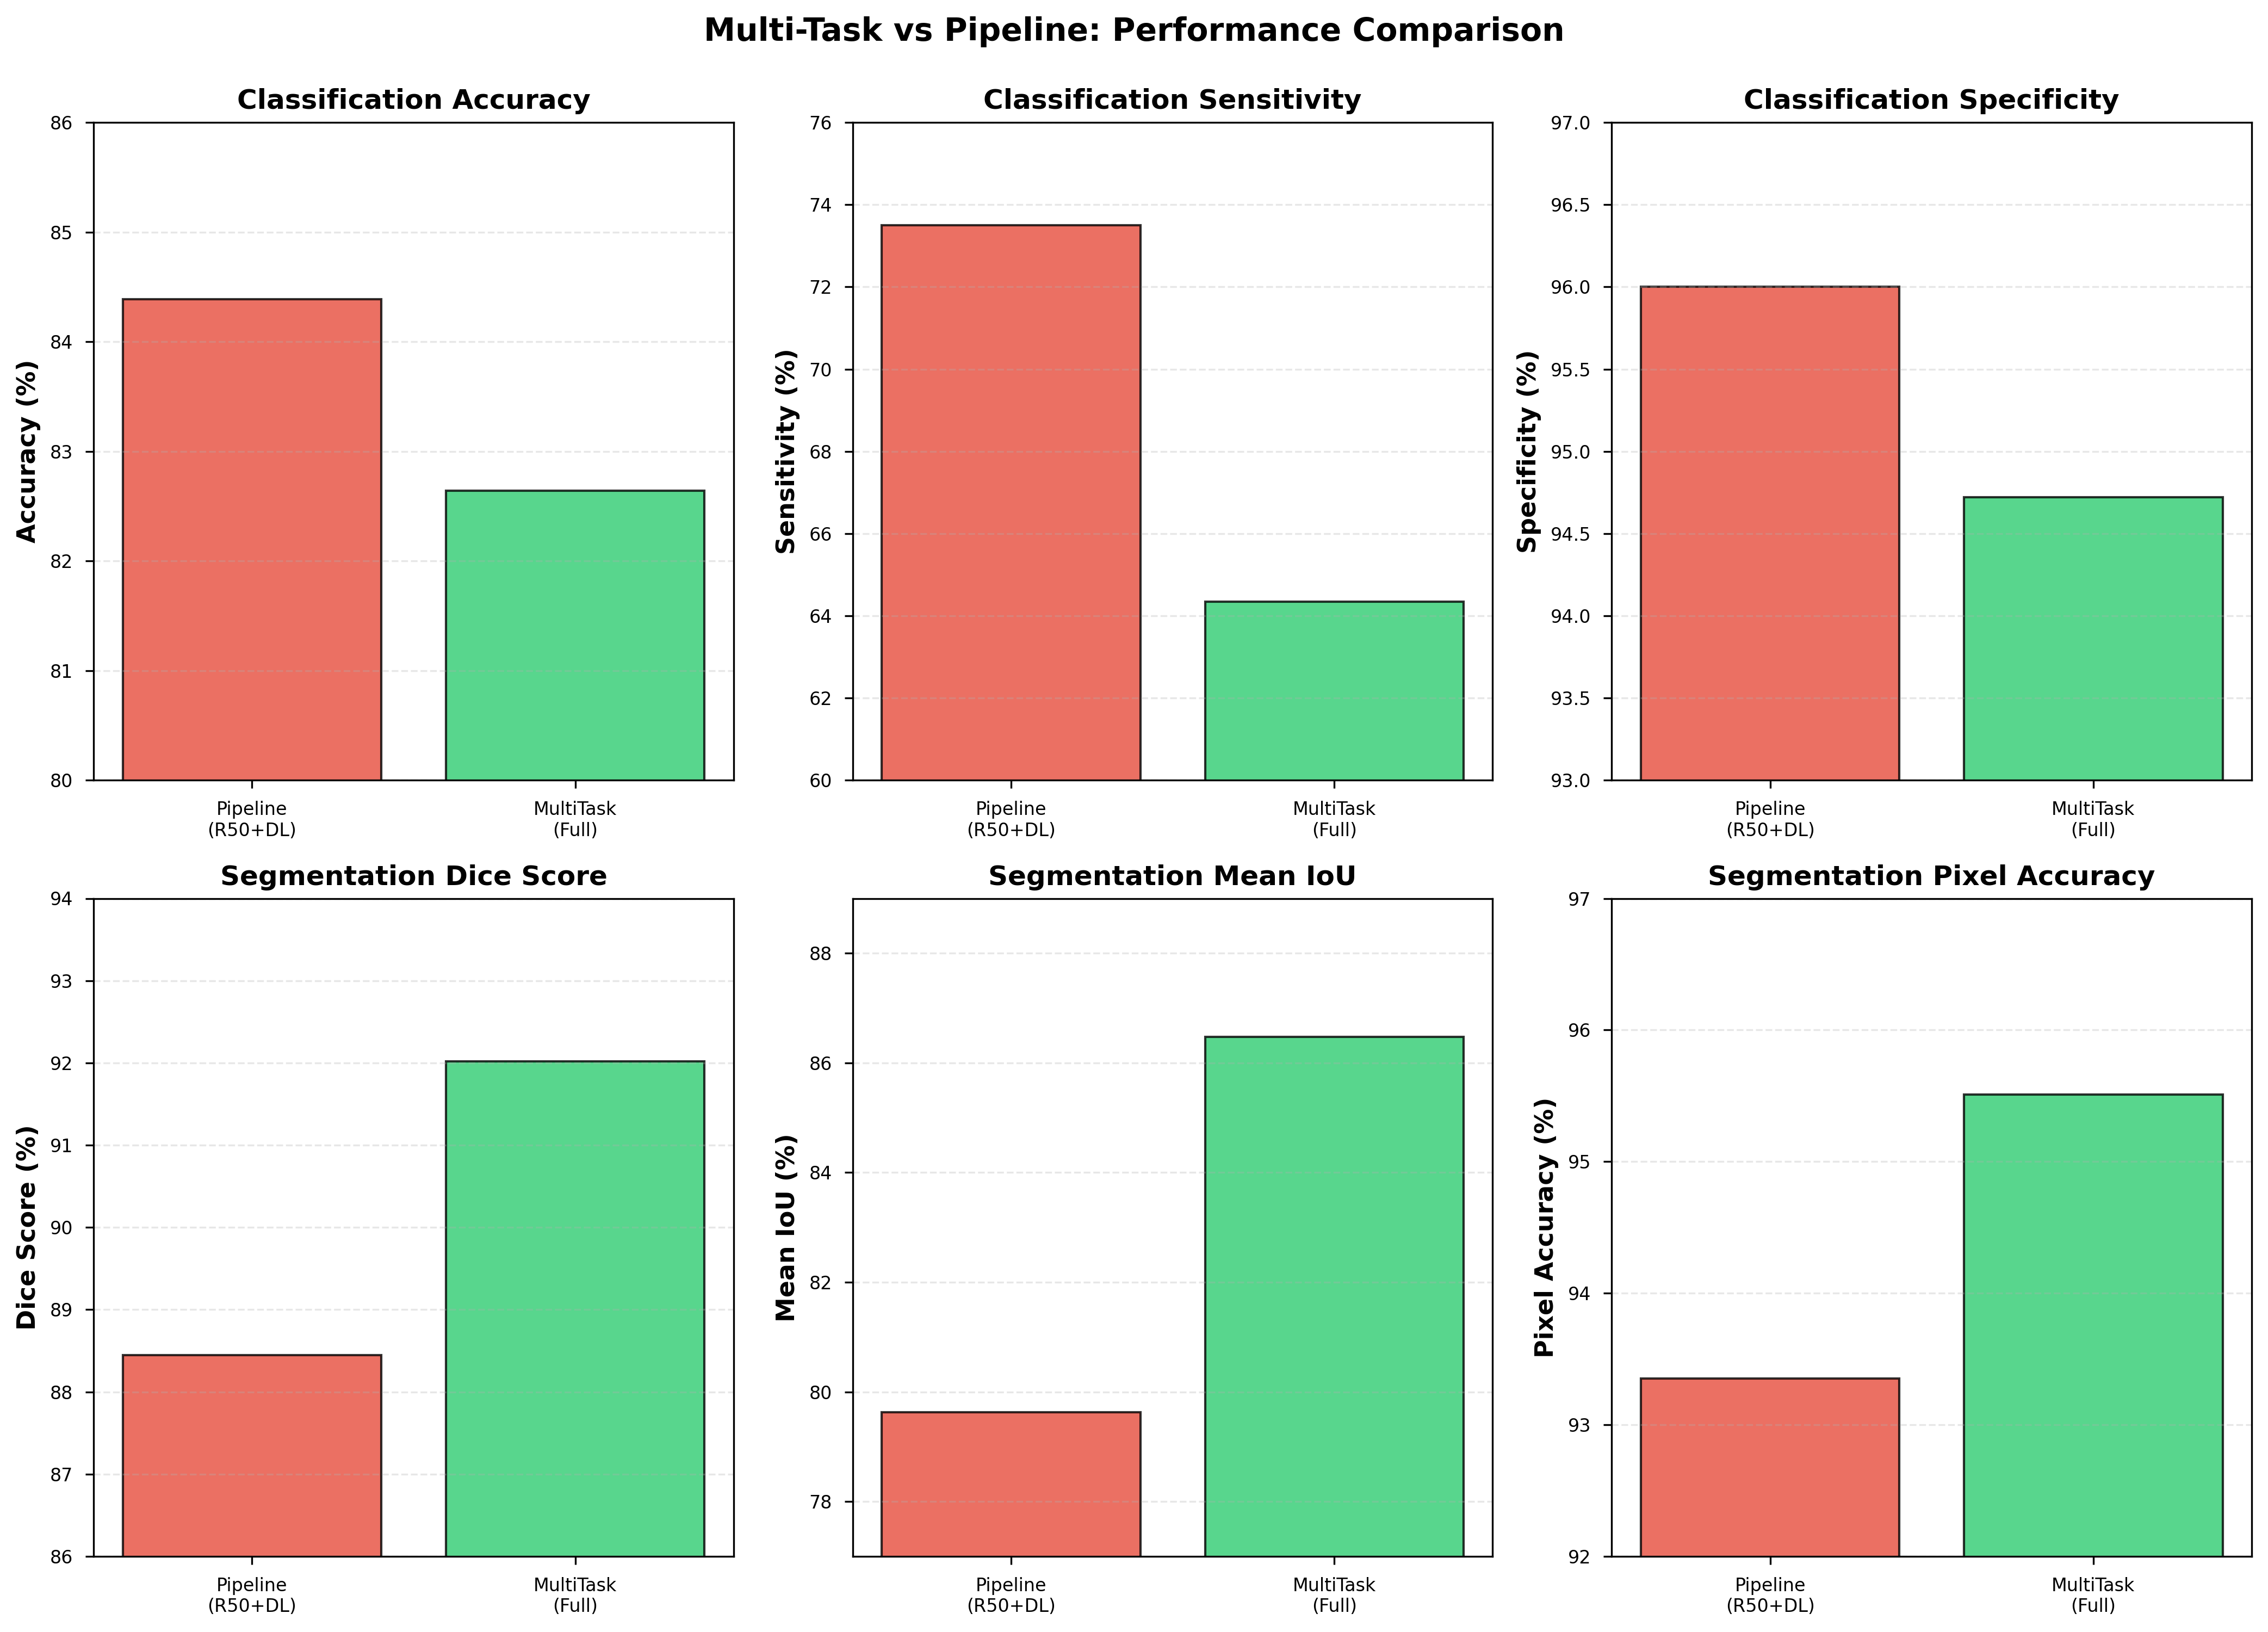

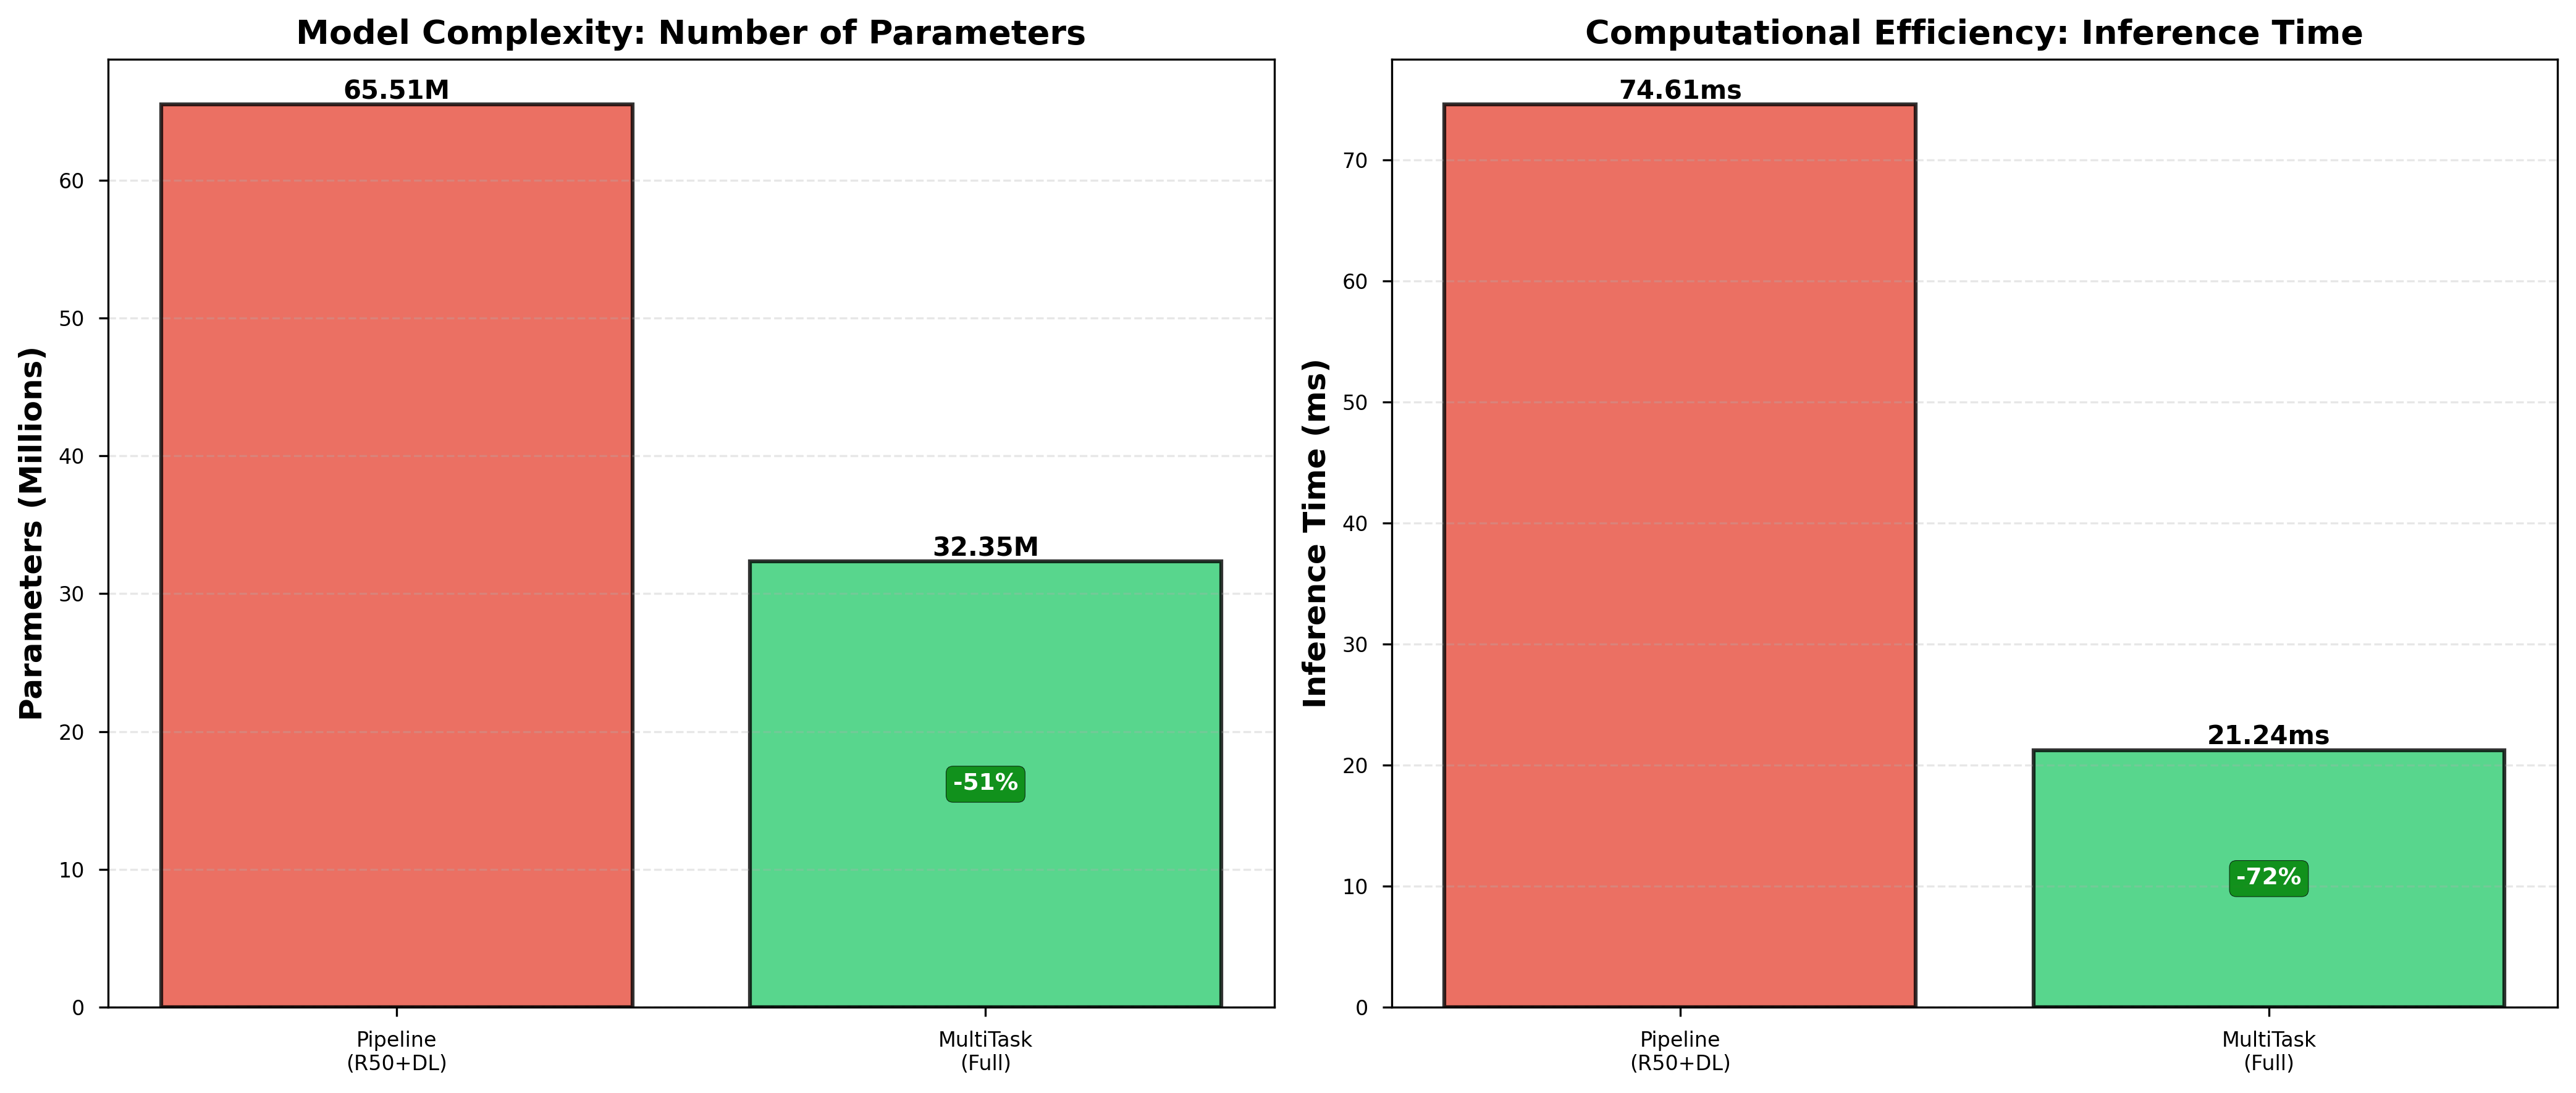


TABLE 5: Multi-Task Models Comparison
              Model  Accuracy (%)  Sensitivity (%)  Specificity (%)  Dice (%)  Mean IoU (%)  Pixel Acc (%)  Parameters (M)  Inference (ms)
   MultiTask (Full)         82.64            64.34            94.72     92.02         86.47          95.51           32.35           21.24
  MultiTask (Mixed)         79.35            58.15            94.25     85.47         77.43          91.78           32.35           21.24
MultiTask (Partial)         78.44            68.57            95.23     86.90         78.91          92.50           32.35           21.24


BEST PERFORMANCE PER METRIC:
  Classification Accuracy: MultiTask (Full) - 82.64%
  Classification Sensitivity: MultiTask (Partial) - 68.57%
  Classification Specificity: MultiTask (Partial) - 95.23%
  Segmentation Dice: MultiTask (Full) - 92.02%
  Segmentation IoU: MultiTask (Full) - 86.47%
  Segmentation Pixel Acc: MultiTask (Full) - 95.51%

NOTE: All three models have identical architecture (32.35

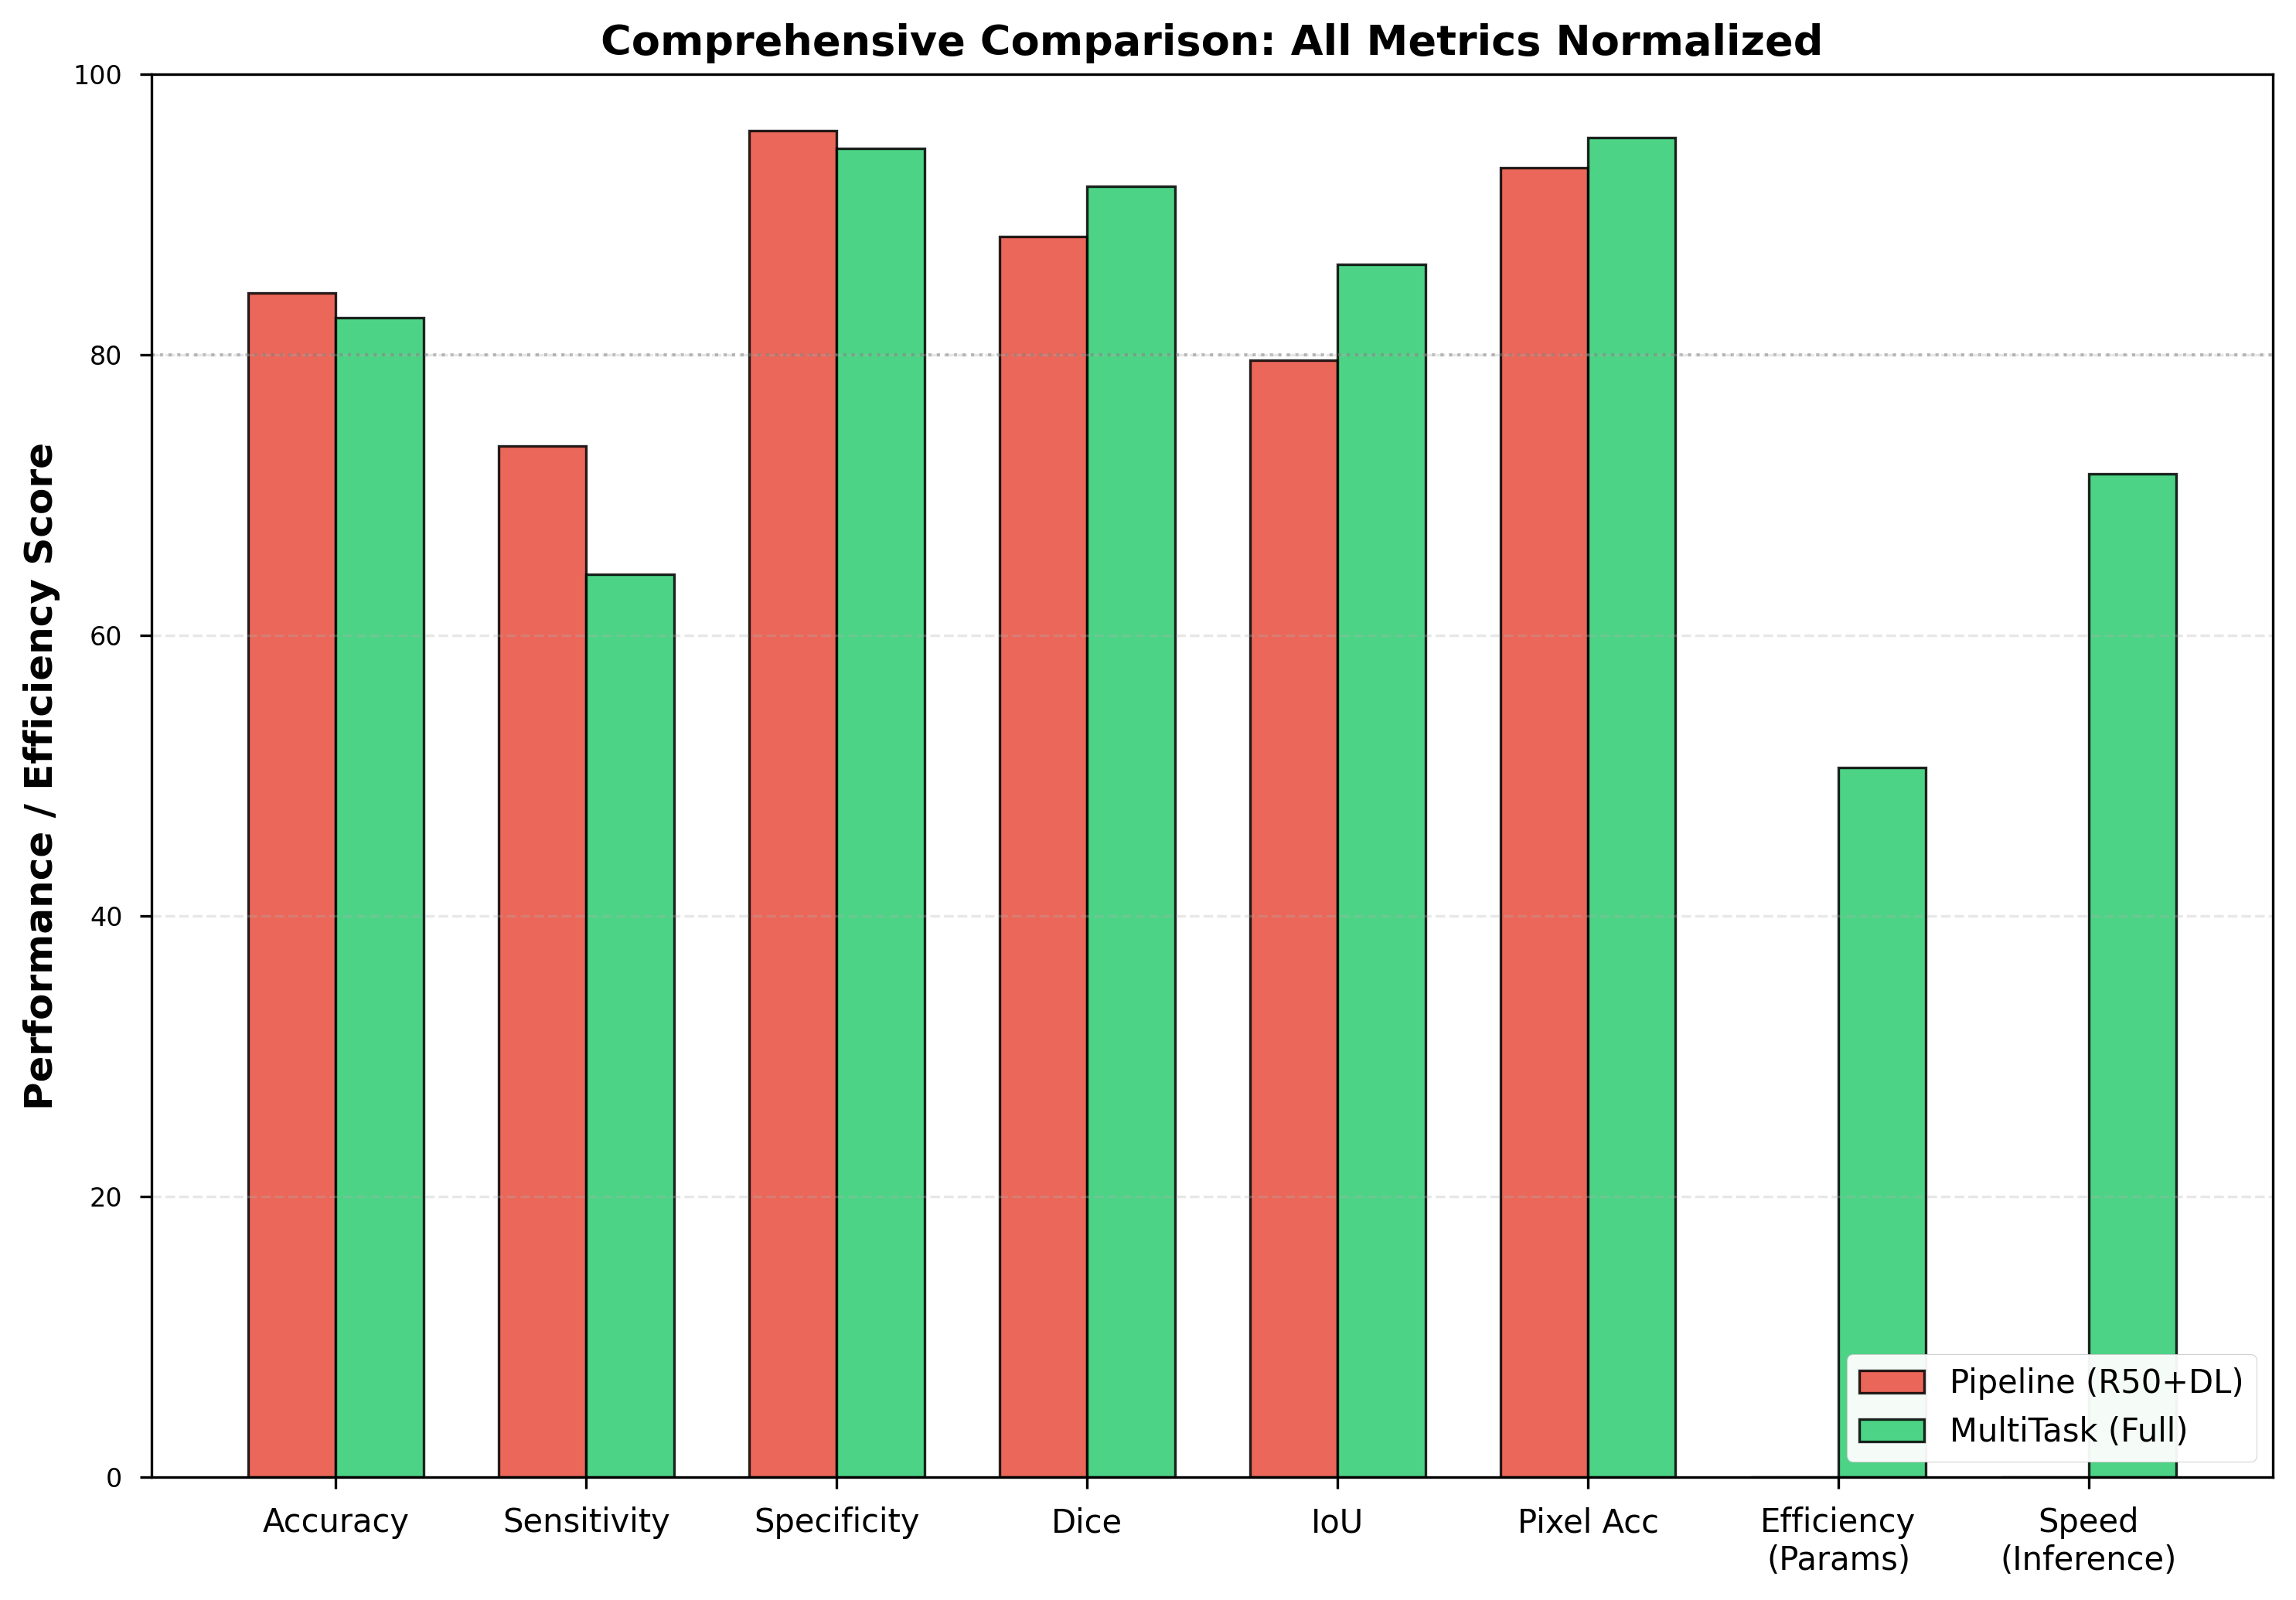

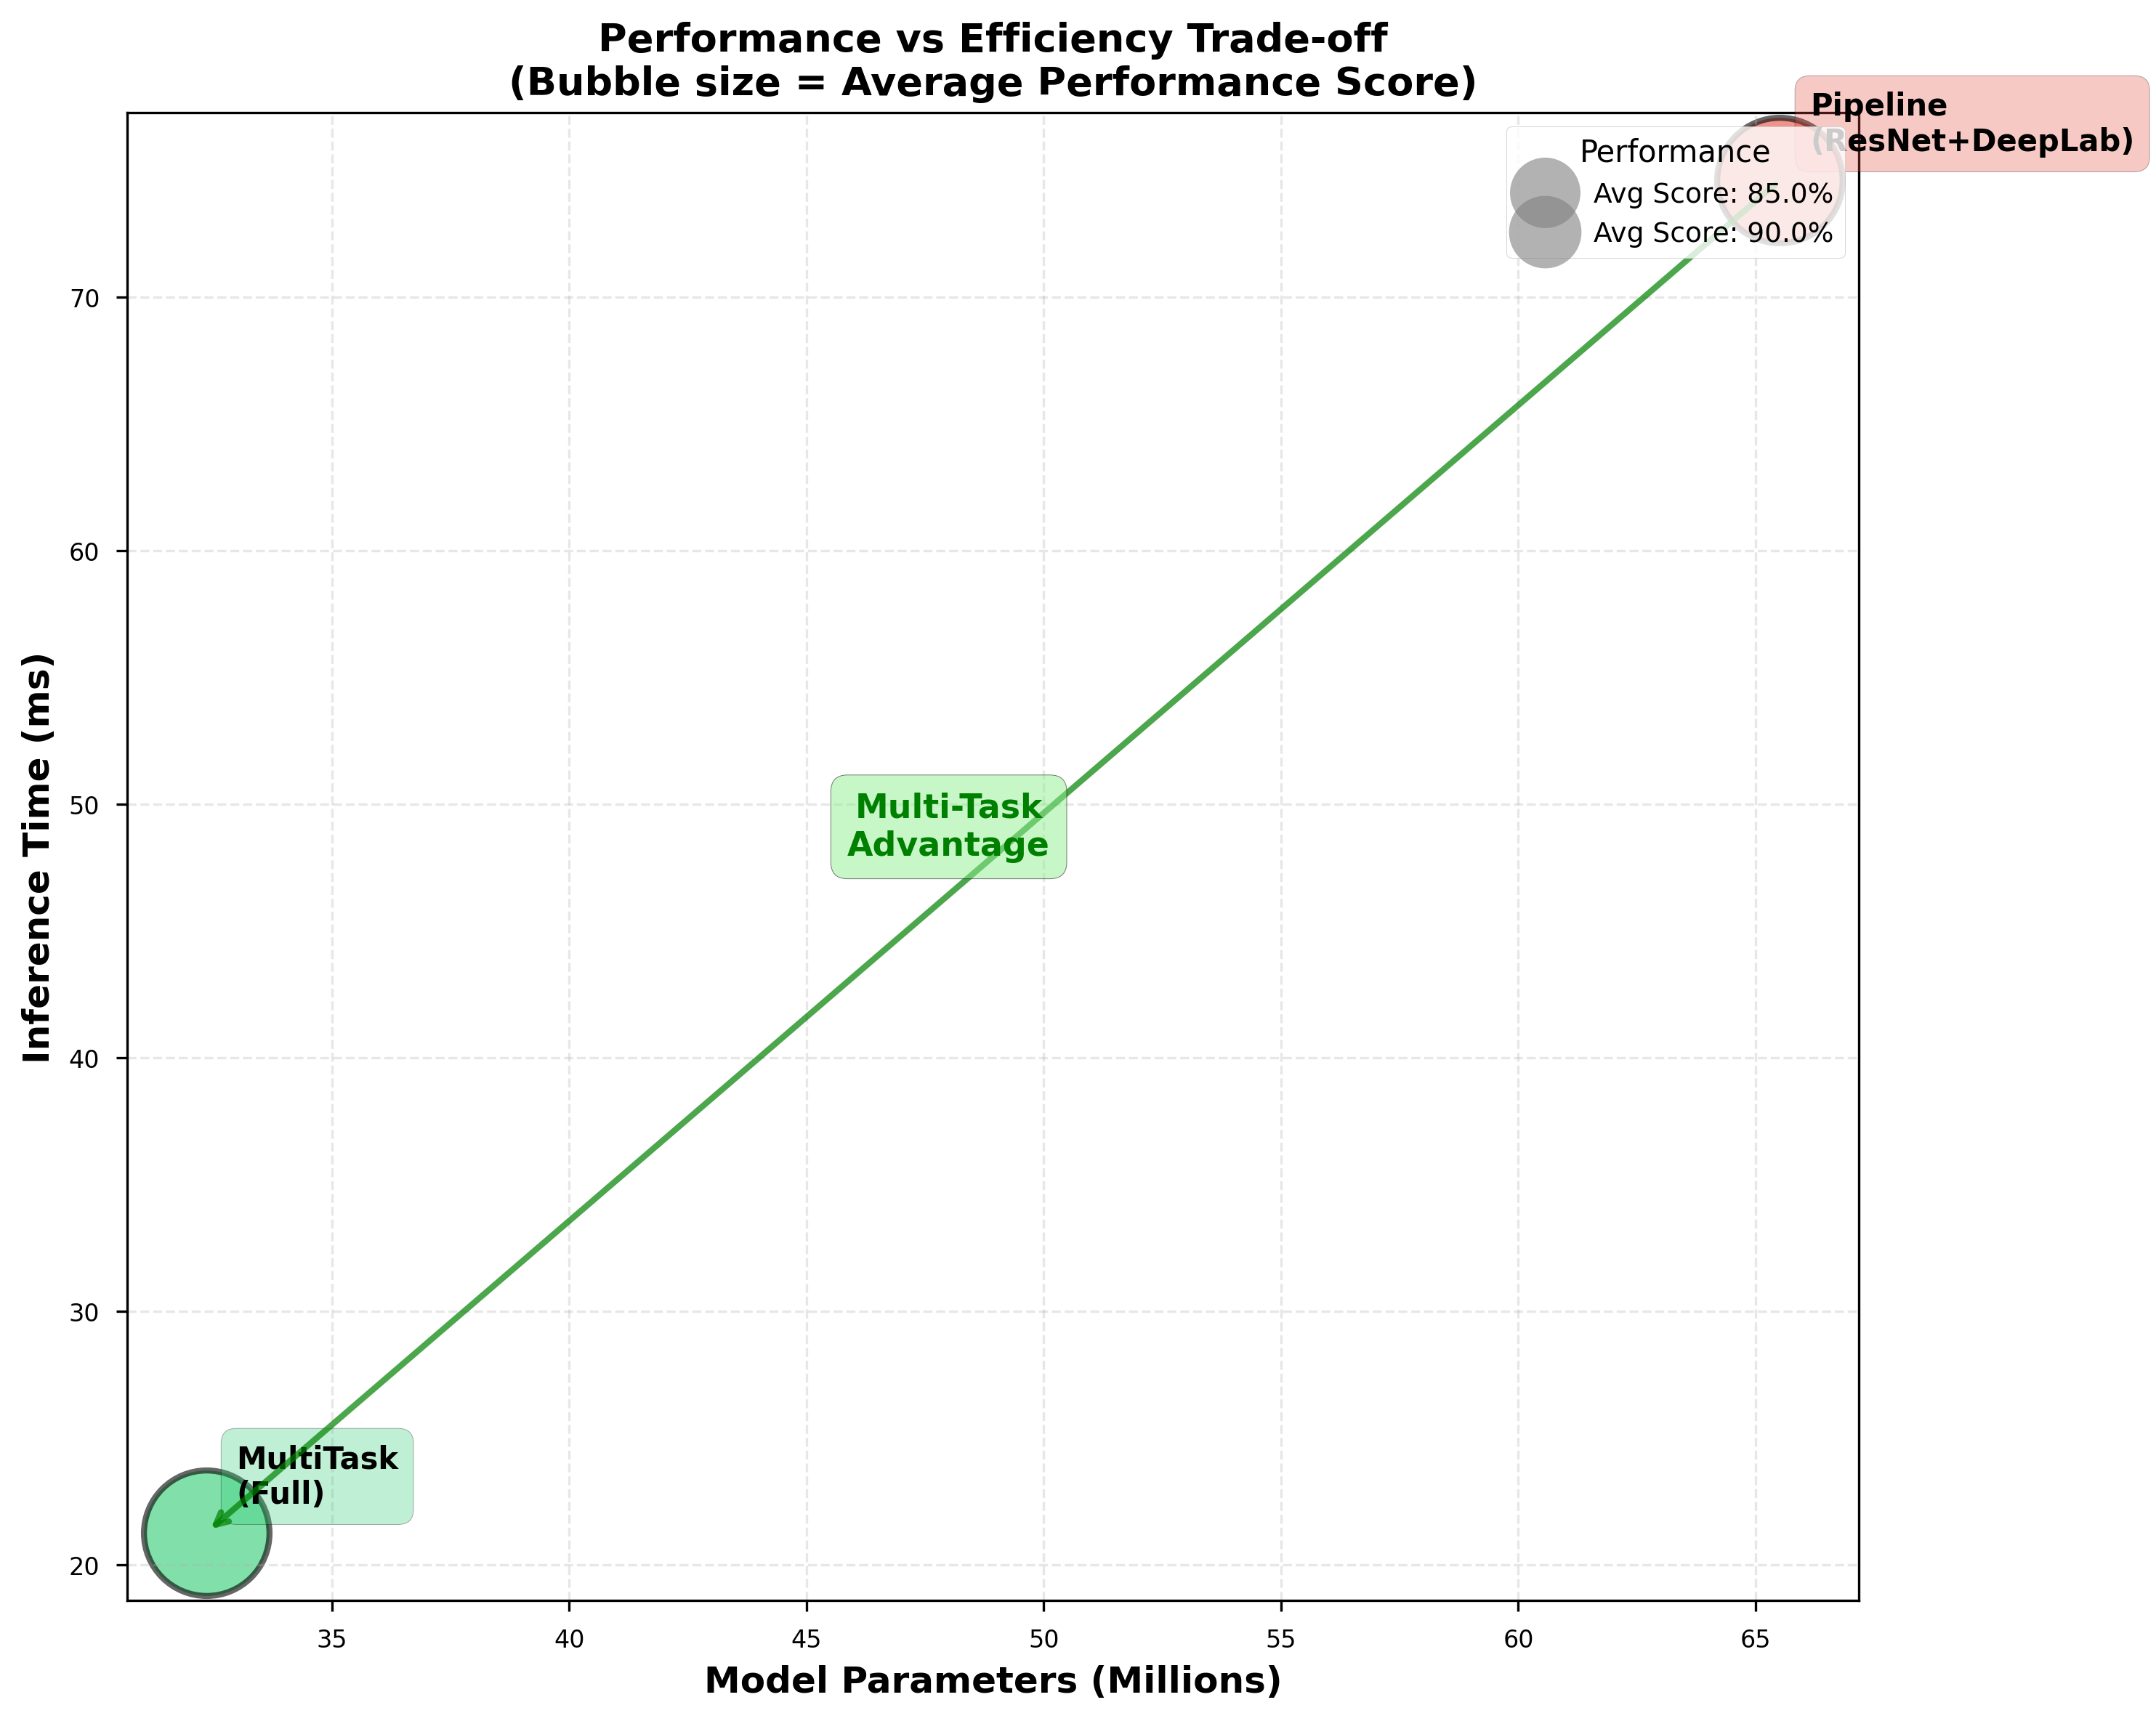

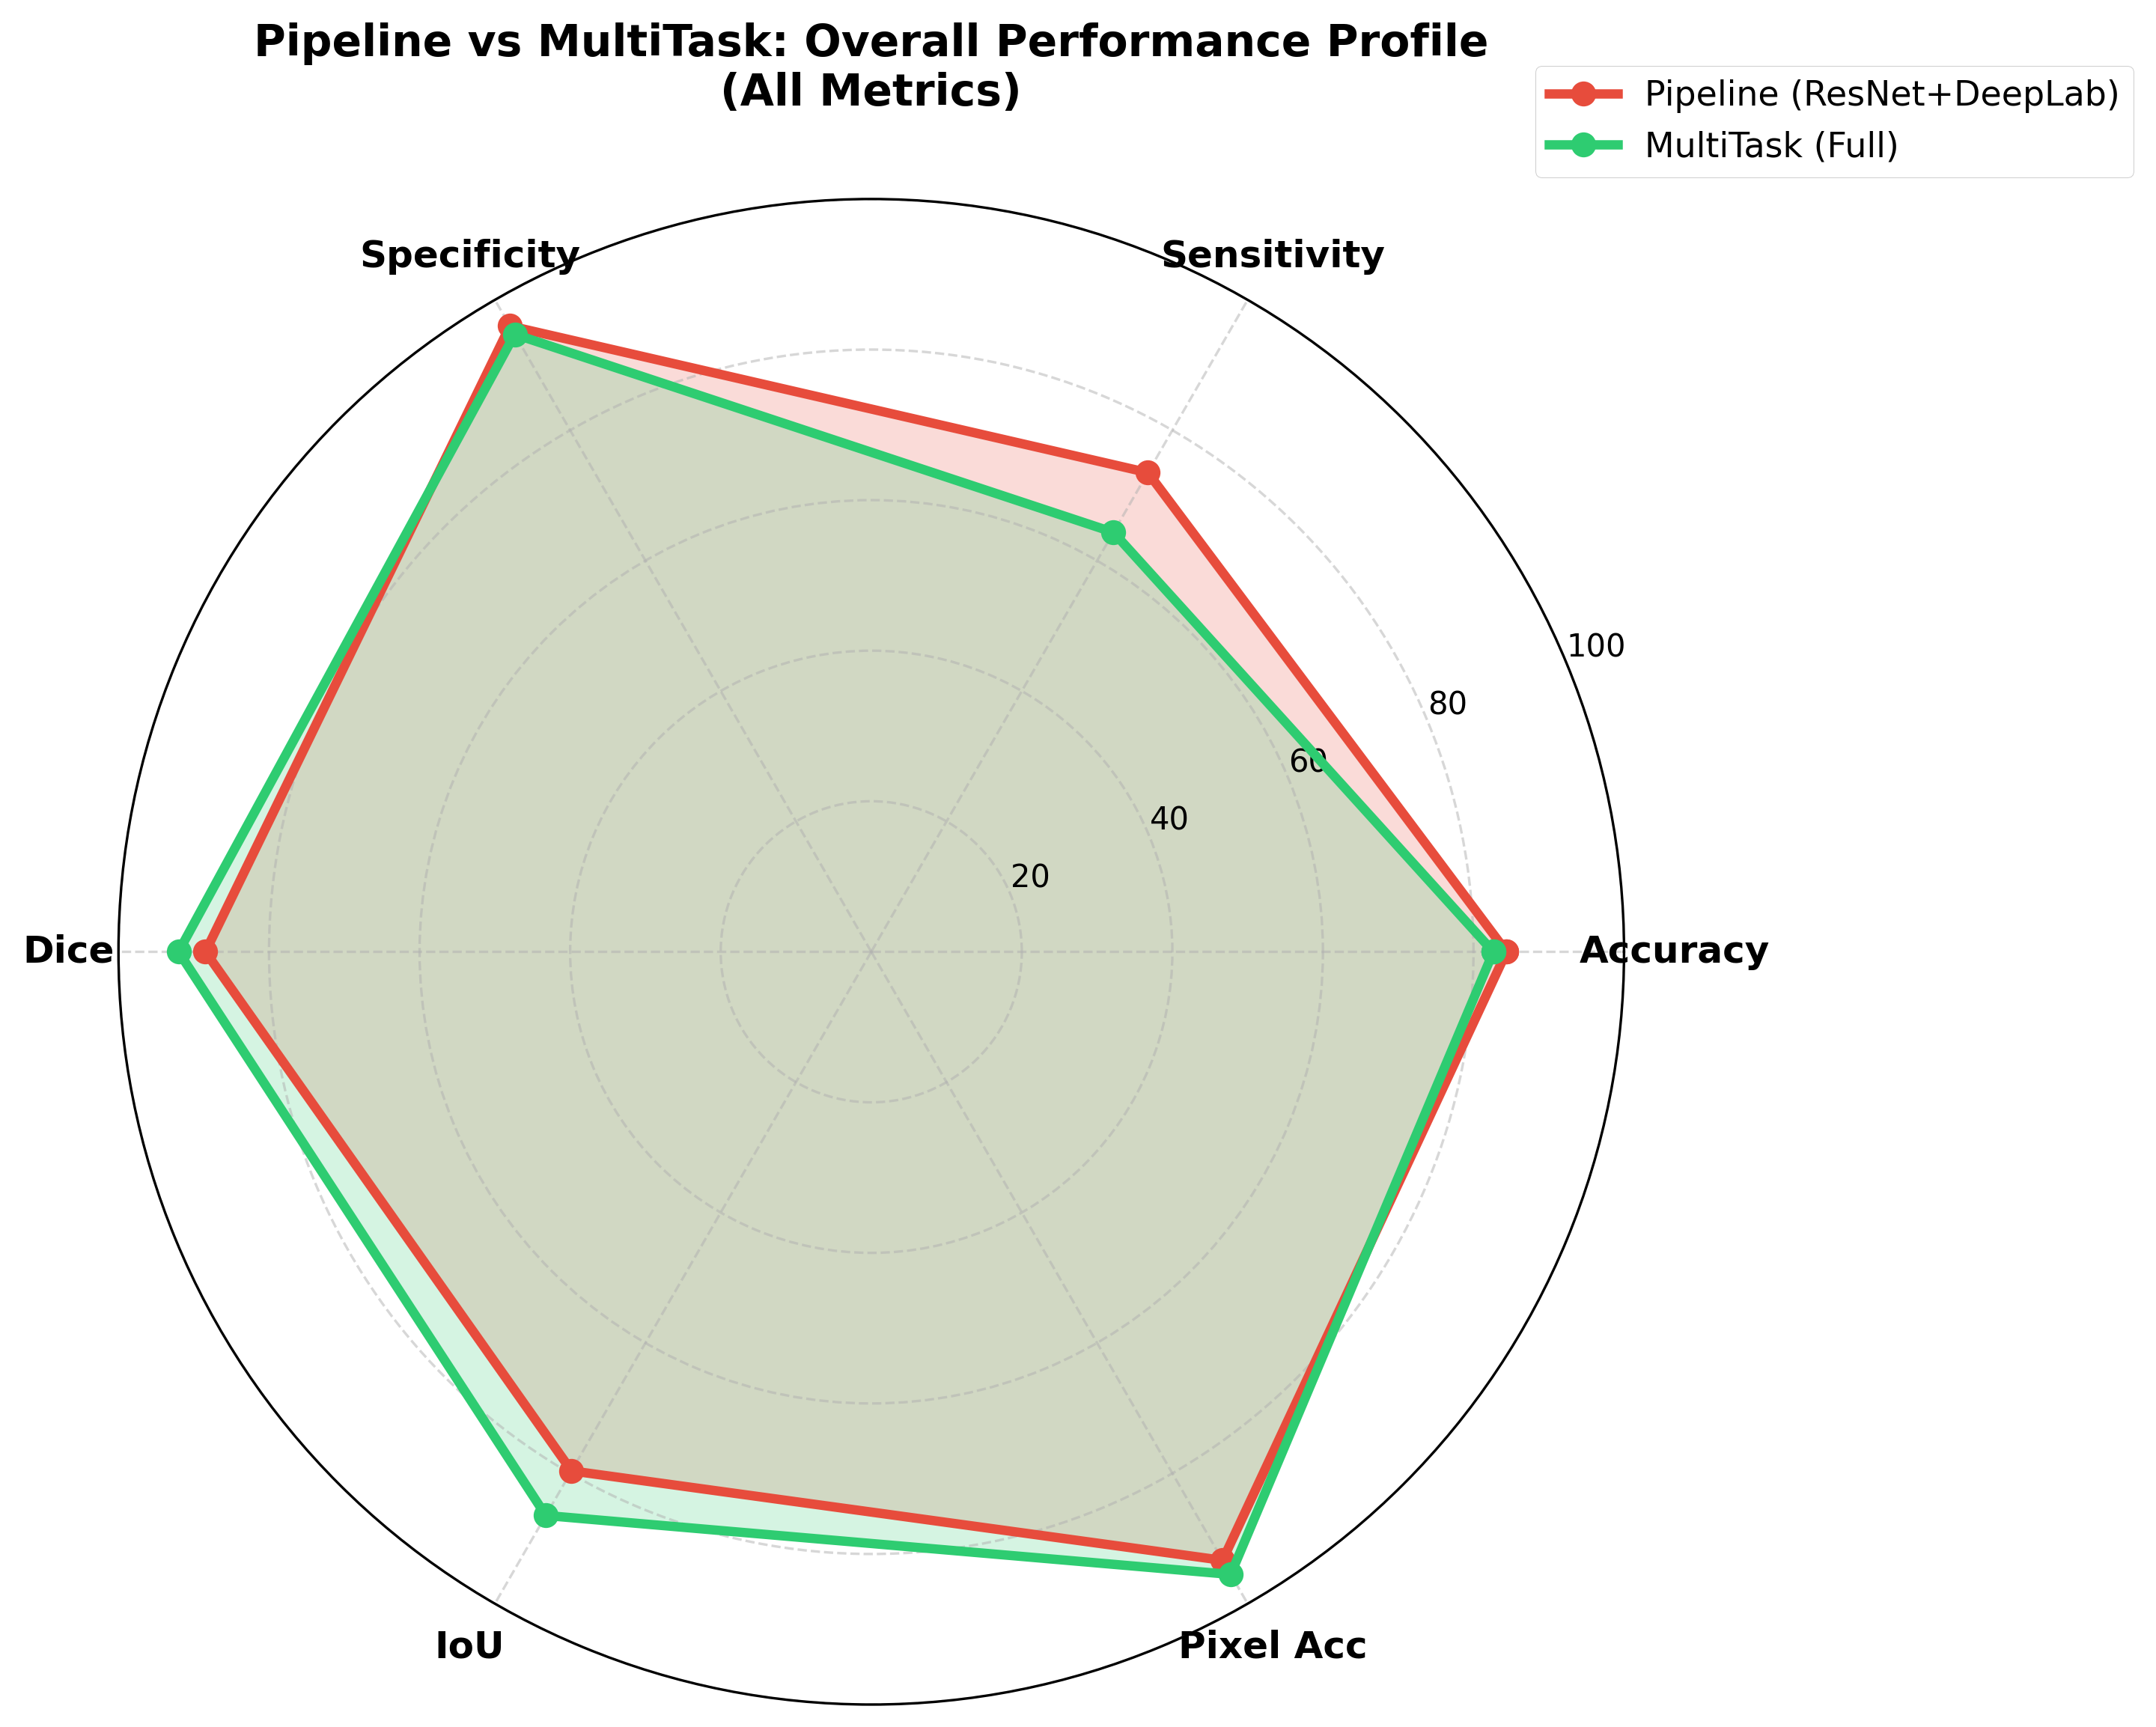

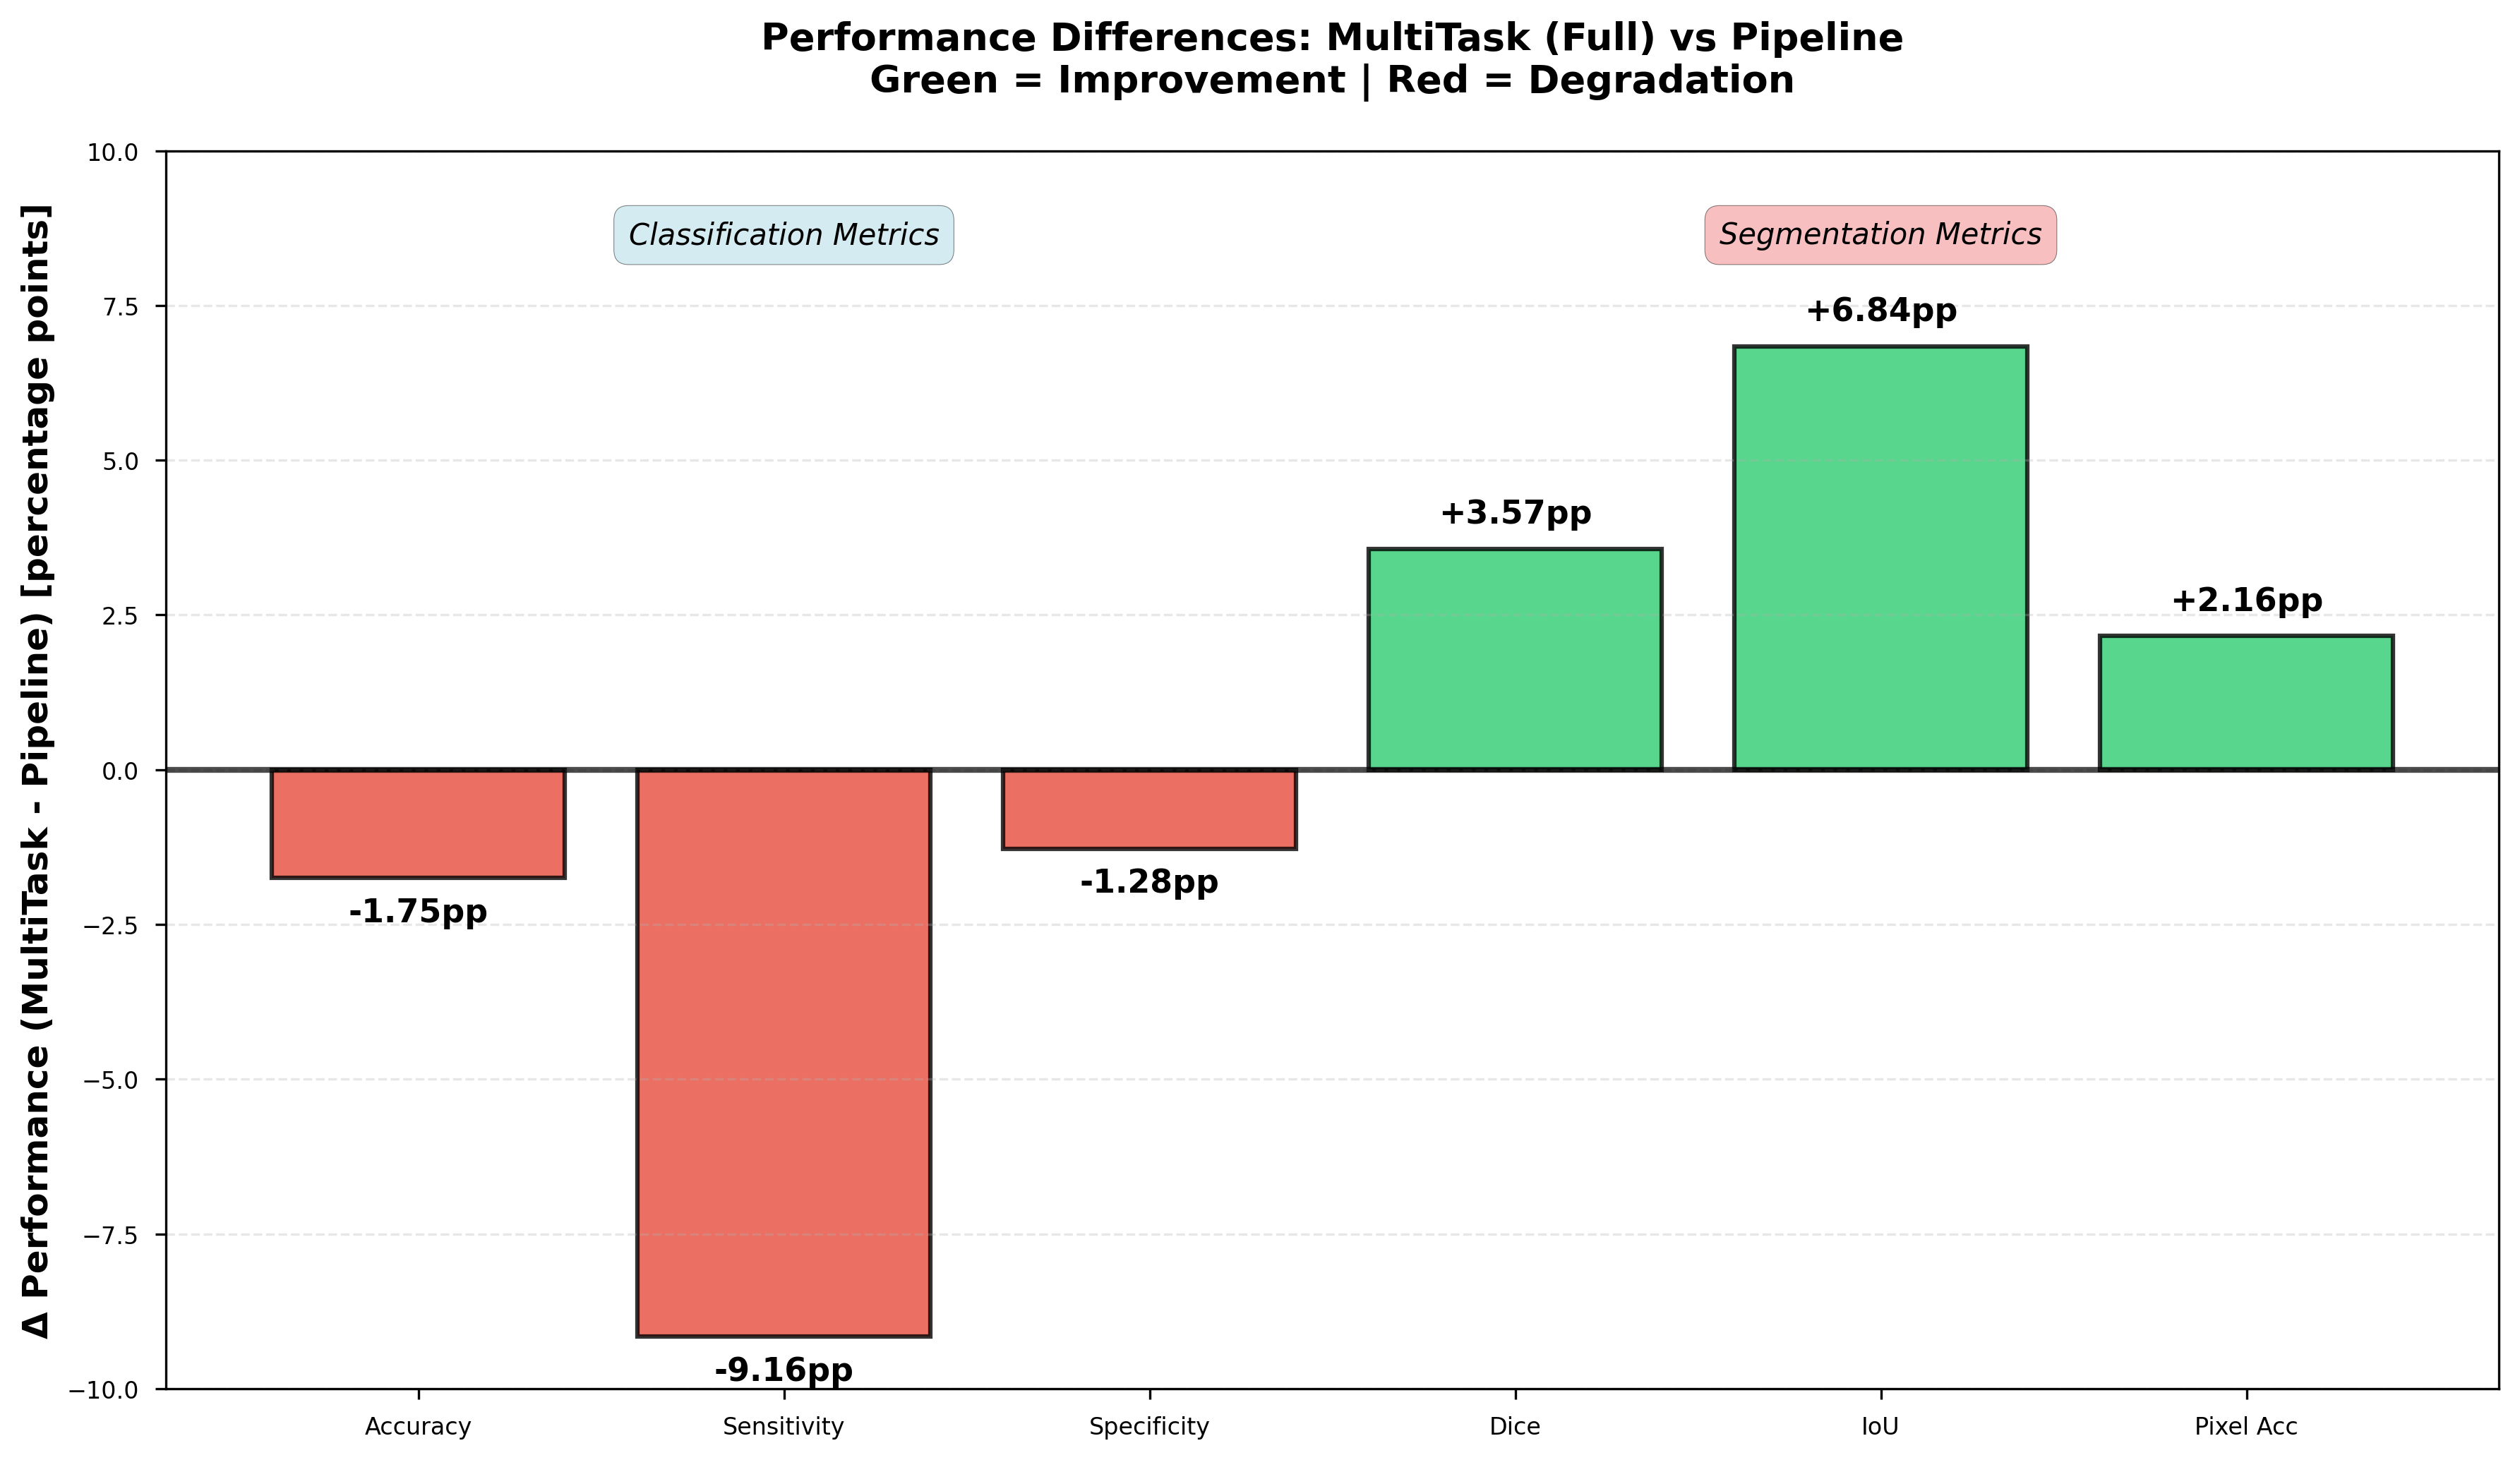


PERFORMANCE DIFFERENCES: MultiTask (Full) vs Pipeline

CLASSIFICATION METRICS:
  Accuracy    :  -1.75pp  [✗ WORSE]
  Sensitivity :  -9.16pp  [✗ WORSE]
  Specificity :  -1.28pp  [✗ WORSE]

SEGMENTATION METRICS:
  Dice        : + +3.57pp  [✓ BETTER]
  IoU         : + +6.84pp  [✓ BETTER]
  Pixel Acc   : + +2.16pp  [✓ BETTER]

OVERALL SUMMARY:
  Improvements:  3/6 metrics
  Degradations:  3/6 metrics
  Trade-off: Significant segmentation gains (+3.57 to +6.84pp) with minor classification losses (-1.28 to -9.16pp)


SUMMARY: Multi-Task vs Pipeline Analysis

KEY FINDINGS:
1. MultiTask (Full) achieves 85.95% average performance
   vs Pipeline's 85.89% (difference: +0.06%)

2. MultiTask models use 50.6% fewer parameters than Pipeline
   (32.35M vs 65.51M)

3. MultiTask models are 71.5% faster in inference
   (21.24ms vs 74.61ms)

4. MultiTask (Full) shows superior segmentation:
   - Dice: 92.02% vs 88.45% (+3.57 pp)
   - IoU: 86.47% vs 79.63% (+6.84 pp)
   - Pixel Acc: 95.51% vs 93.35% (+2.16

In [32]:
# ============================================================================
# MULTI-TASK vs PIPELINE COMPARISON
# ============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Pipeline approach: ResNet-50 + DeepLabV3 (separate models)
pipeline_approach = {
    'accuracy': 84.39,  # from ResNet-50
    'sensitivity': 73.50,  # from ResNet-50
    'specificity': 96.00,  # from ResNet-50
    'dice': 88.45,  # from DeepLabV3
    'mean_iou': 79.63,  # from DeepLabV3
    'pixel_accuracy': 93.35,  # from DeepLabV3
    'parameters': 23.52 + 41.99,  # ResNet-50 + DeepLabV3 = 65.51M
    'inference_time': 10.049 + 64.565  # ResNet-50 + DeepLabV3 = 74.614ms
}

# Multi-task models (already defined)
multitask_full = {
    'accuracy': 82.64, 'sensitivity': 64.34, 'specificity': 94.72,
    'dice': 92.02, 'mean_iou': 86.47, 'pixel_accuracy': 95.51,
    'parameters': 32.35, 'inference_time': 21.24
}

multitask_mixed = {
    'accuracy': 79.35, 'sensitivity': 58.15, 'specificity': 94.25,
    'dice': 85.47, 'mean_iou': 77.43, 'pixel_accuracy': 91.78,
    'parameters': 32.35, 'inference_time': 21.24
}

multitask_partial = {
    'accuracy': 78.44, 'sensitivity': 68.57, 'specificity': 95.23,
    'dice': 86.90, 'mean_iou': 78.91, 'pixel_accuracy': 92.50,
    'parameters': 32.35, 'inference_time': 21.24
}

# ============================================================================
# TABLE 4: Multi-Task vs Pipeline Comparison
# ============================================================================
print("\n" + "=" * 80)
print("TABLE 4: Multi-Task (Full) vs Pipeline Approach (ResNet-50 + DeepLabV3)")
print("=" * 80)

comparison_pipeline = {
    'Approach': ['Pipeline (ResNet+DeepLab)', 'MultiTask (Full)'],
    'Accuracy (%)': [84.39, 82.64],
    'Sensitivity (%)': [73.50, 64.34],
    'Specificity (%)': [96.00, 94.72],
    'Dice (%)': [88.45, 92.02],
    'Mean IoU (%)': [79.63, 86.47],
    'Pixel Acc (%)': [93.35, 95.51],
    'Parameters (M)': [65.51, 32.35],
    'Inference (ms)': [74.61, 21.24]
}

df_pipeline = pd.DataFrame(comparison_pipeline)
print(df_pipeline.to_string(index=False))
print("\n")

# Calculate efficiency gains
print("EFFICIENCY GAINS OF MULTI-TASK (FULL) vs PIPELINE:")
print(f"  Parameter Reduction: {((65.51 - 32.35) / 65.51 * 100):.1f}%")
print(f"  Inference Time Reduction: {((74.61 - 21.24) / 74.61 * 100):.1f}%")
print(f"  Dice Score Improvement: {(92.02 - 88.45):.2f} percentage points (+{((92.02 - 88.45) / 88.45 * 100):.1f}%)")
print(f"  Mean IoU Improvement: {(86.47 - 79.63):.2f} percentage points (+{((86.47 - 79.63) / 79.63 * 100):.1f}%)")
print("=" * 80 + "\n")

# ============================================================================
# FIGURE 7: Multi-Task vs Pipeline - Key Metrics Comparison
# ============================================================================
fig, axes = plt.subplots(2, 3, figsize=(14, 10))

approaches = ['Pipeline\n(R50+DL)', 'MultiTask\n(Full)']
colors_pipeline = ['#e74c3c', '#2ecc71']

# Classification Accuracy
acc_vals = [84.39, 82.64]
axes[0, 0].bar(approaches, acc_vals, color=colors_pipeline, alpha=0.8, edgecolor='black', linewidth=1)
axes[0, 0].set_ylabel('Accuracy (%)', fontweight='bold')
axes[0, 0].set_title('Classification Accuracy', fontweight='bold')
axes[0, 0].set_ylim([80, 86])
axes[0, 0].grid(axis='y', alpha=0.3, linestyle='--')
axes[0, 0].tick_params(axis='x', rotation=0)

# Classification Sensitivity
sens_vals = [73.50, 64.34]
axes[0, 1].bar(approaches, sens_vals, color=colors_pipeline, alpha=0.8, edgecolor='black', linewidth=1)
axes[0, 1].set_ylabel('Sensitivity (%)', fontweight='bold')
axes[0, 1].set_title('Classification Sensitivity', fontweight='bold')
axes[0, 1].set_ylim([60, 76])
axes[0, 1].grid(axis='y', alpha=0.3, linestyle='--')
axes[0, 1].tick_params(axis='x', rotation=0)

# Classification Specificity
spec_vals = [96.00, 94.72]
axes[0, 2].bar(approaches, spec_vals, color=colors_pipeline, alpha=0.8, edgecolor='black', linewidth=1)
axes[0, 2].set_ylabel('Specificity (%)', fontweight='bold')
axes[0, 2].set_title('Classification Specificity', fontweight='bold')
axes[0, 2].set_ylim([93, 97])
axes[0, 2].grid(axis='y', alpha=0.3, linestyle='--')
axes[0, 2].tick_params(axis='x', rotation=0)

# Segmentation Dice
dice_vals = [88.45, 92.02]
axes[1, 0].bar(approaches, dice_vals, color=colors_pipeline, alpha=0.8, edgecolor='black', linewidth=1)
axes[1, 0].set_ylabel('Dice Score (%)', fontweight='bold')
axes[1, 0].set_title('Segmentation Dice Score', fontweight='bold')
axes[1, 0].set_ylim([86, 94])
axes[1, 0].grid(axis='y', alpha=0.3, linestyle='--')
axes[1, 0].tick_params(axis='x', rotation=0)

# Segmentation Mean IoU
iou_vals = [79.63, 86.47]
axes[1, 1].bar(approaches, iou_vals, color=colors_pipeline, alpha=0.8, edgecolor='black', linewidth=1)
axes[1, 1].set_ylabel('Mean IoU (%)', fontweight='bold')
axes[1, 1].set_title('Segmentation Mean IoU', fontweight='bold')
axes[1, 1].set_ylim([77, 89])
axes[1, 1].grid(axis='y', alpha=0.3, linestyle='--')
axes[1, 1].tick_params(axis='x', rotation=0)

# Segmentation Pixel Accuracy
pix_vals = [93.35, 95.51]
axes[1, 2].bar(approaches, pix_vals, color=colors_pipeline, alpha=0.8, edgecolor='black', linewidth=1)
axes[1, 2].set_ylabel('Pixel Accuracy (%)', fontweight='bold')
axes[1, 2].set_title('Segmentation Pixel Accuracy', fontweight='bold')
axes[1, 2].set_ylim([92, 97])
axes[1, 2].grid(axis='y', alpha=0.3, linestyle='--')
axes[1, 2].tick_params(axis='x', rotation=0)

plt.suptitle('Multi-Task vs Pipeline: Performance Comparison', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('../paper_images/multitask_vs_pipeline_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# FIGURE 8: Efficiency Gains - Parameters and Inference Time
# ============================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Parameters comparison
params_vals = [65.51, 32.35]
bars1 = ax1.bar(approaches, params_vals, color=colors_pipeline, alpha=0.8, edgecolor='black', linewidth=1.5)
ax1.set_ylabel('Parameters (Millions)', fontweight='bold', fontsize=12)
ax1.set_title('Model Complexity: Number of Parameters', fontweight='bold', fontsize=13)
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.tick_params(axis='x', rotation=0)

# Add value labels and percentage reduction
for i, (bar, val) in enumerate(zip(bars1, params_vals)):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.2f}M', ha='center', va='bottom', fontsize=10, fontweight='bold')
    if i > 0:  # For multi-task model
        reduction = ((65.51 - val) / 65.51) * 100
        ax1.text(bar.get_x() + bar.get_width()/2., height/2,
                f'-{reduction:.0f}%', ha='center', va='center', 
                fontsize=9, color='white', fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='green', alpha=0.8))

# Inference time comparison
infer_vals = [74.61, 21.24]
bars2 = ax2.bar(approaches, infer_vals, color=colors_pipeline, alpha=0.8, edgecolor='black', linewidth=1.5)
ax2.set_ylabel('Inference Time (ms)', fontweight='bold', fontsize=12)
ax2.set_title('Computational Efficiency: Inference Time', fontweight='bold', fontsize=13)
ax2.grid(axis='y', alpha=0.3, linestyle='--')
ax2.tick_params(axis='x', rotation=0)

# Add value labels and percentage reduction
for i, (bar, val) in enumerate(zip(bars2, infer_vals)):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.2f}ms', ha='center', va='bottom', fontsize=10, fontweight='bold')
    if i > 0:  # For multi-task model
        reduction = ((74.61 - val) / 74.61) * 100
        ax2.text(bar.get_x() + bar.get_width()/2., height/2,
                f'-{reduction:.0f}%', ha='center', va='center', 
                fontsize=9, color='white', fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='green', alpha=0.8))

plt.tight_layout()
plt.savefig('../paper_images/efficiency_gains_parameters_inference.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# TABLE 5: Multi-Task Models Only Comparison
# ============================================================================
print("\n" + "=" * 80)
print("TABLE 5: Multi-Task Models Comparison")
print("=" * 80)

comparison_multitask_only = {
    'Model': ['MultiTask (Full)', 'MultiTask (Mixed)', 'MultiTask (Partial)'],
    'Accuracy (%)': [82.64, 79.35, 78.44],
    'Sensitivity (%)': [64.34, 58.15, 68.57],
    'Specificity (%)': [94.72, 94.25, 95.23],
    'Dice (%)': [92.02, 85.47, 86.90],
    'Mean IoU (%)': [86.47, 77.43, 78.91],
    'Pixel Acc (%)': [95.51, 91.78, 92.50],
    'Parameters (M)': [32.35, 32.35, 32.35],
    'Inference (ms)': [21.24, 21.24, 21.24]
}

df_multitask_only = pd.DataFrame(comparison_multitask_only)
print(df_multitask_only.to_string(index=False))
print("\n")

# Highlight best performance in each metric
print("BEST PERFORMANCE PER METRIC:")
print(f"  Classification Accuracy: MultiTask (Full) - {82.64}%")
print(f"  Classification Sensitivity: MultiTask (Partial) - {68.57}%")
print(f"  Classification Specificity: MultiTask (Partial) - {95.23}%")
print(f"  Segmentation Dice: MultiTask (Full) - {92.02}%")
print(f"  Segmentation IoU: MultiTask (Full) - {86.47}%")
print(f"  Segmentation Pixel Acc: MultiTask (Full) - {95.51}%")
print("\nNOTE: All three models have identical architecture (32.35M params, 21.24ms inference)")
print("      Differences arise from training data composition:")
print("      - Full: 100% paired labels")
print("      - Mixed: 50% paired + 25% cls-only + 25% seg-only")
print("      - Partial: Same split as Mixed, different data distribution")
print("=" * 80 + "\n")

# ============================================================================
# FIGURE 9: Comprehensive Comparison - Normalized Metrics
# ============================================================================
fig, ax = plt.subplots(figsize=(10, 7))

# Normalize all metrics to 0-1 scale (higher is better)
# For parameters and inference time, use inverse (1 - normalized) so higher is better
metrics_names = ['Accuracy', 'Sensitivity', 'Specificity', 'Dice', 'IoU', 'Pixel Acc', 
                 'Efficiency\n(Params)', 'Speed\n(Inference)']

# Normalize each metric to 0-100 scale
pipeline_norm = [
    84.39, 73.50, 96.00, 88.45, 79.63, 93.35,
    100 * (1 - 65.51/65.51),  # Worst case = 0
    100 * (1 - 74.61/74.61)   # Worst case = 0
]

multitask_full_norm = [
    82.64, 64.34, 94.72, 92.02, 86.47, 95.51,
    100 * (1 - 32.35/65.51),  # Better = higher
    100 * (1 - 21.24/74.61)   # Better = higher
]

x = np.arange(len(metrics_names))
width = 0.35

bars1 = ax.bar(x - width/2, pipeline_norm, width, label='Pipeline (R50+DL)', 
               color='#e74c3c', alpha=0.85, edgecolor='black', linewidth=0.8)
bars2 = ax.bar(x + width/2, multitask_full_norm, width, label='MultiTask (Full)', 
               color='#2ecc71', alpha=0.85, edgecolor='black', linewidth=0.8)

ax.set_ylabel('Performance / Efficiency Score', fontweight='bold', fontsize=12)
ax.set_title('Comprehensive Comparison: All Metrics Normalized', fontweight='bold', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(metrics_names, fontsize=10)
ax.legend(loc='lower right', fontsize=10, framealpha=0.95)
ax.set_ylim([0, 100])
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.axhline(y=80, color='gray', linestyle=':', linewidth=1, alpha=0.5)

plt.tight_layout()
plt.savefig('../paper_images/comprehensive_normalized_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# FIGURE 10: Performance vs Efficiency Trade-off Scatter
# ============================================================================
fig, ax = plt.subplots(figsize=(10, 8))

# Calculate average performance score (mean of all 6 metrics)
def avg_performance(acc, sens, spec, dice, iou, pix):
    return (acc + sens + spec + dice + iou + pix) / 6

pipeline_perf = avg_performance(84.39, 73.50, 96.00, 88.45, 79.63, 93.35)
full_perf = avg_performance(82.64, 64.34, 94.72, 92.02, 86.47, 95.51)

performances = [pipeline_perf, full_perf]
params_scatter = [65.51, 32.35]
inference_scatter = [74.61, 21.24]
labels_scatter = ['Pipeline\n(ResNet+DeepLab)', 'MultiTask\n(Full)']
colors_scatter = ['#e74c3c', '#2ecc71']

# Create bubble chart: x=params, y=inference, size=performance
sizes = [p * 20 for p in performances]  # Scale for visibility

for i in range(len(labels_scatter)):
    ax.scatter(params_scatter[i], inference_scatter[i], s=sizes[i], 
              c=colors_scatter[i], alpha=0.6, edgecolors='black', linewidth=2)
    ax.annotate(labels_scatter[i], (params_scatter[i], inference_scatter[i]),
               xytext=(10, 10), textcoords='offset points', fontsize=10,
               fontweight='bold',
               bbox=dict(boxstyle='round,pad=0.5', facecolor=colors_scatter[i], 
                        alpha=0.3, edgecolor='black'))

# Add arrows showing improvement
ax.annotate('', xy=(32.35, 21.24), xytext=(65.51, 74.61),
           arrowprops=dict(arrowstyle='->', lw=2, color='green', alpha=0.7))
ax.text(48, 48, 'Multi-Task\nAdvantage', fontsize=11, fontweight='bold', 
       ha='center', color='green',
       bbox=dict(boxstyle='round,pad=0.5', facecolor='lightgreen', alpha=0.5))

ax.set_xlabel('Model Parameters (Millions)', fontweight='bold', fontsize=12)
ax.set_ylabel('Inference Time (ms)', fontweight='bold', fontsize=12)
ax.set_title('Performance vs Efficiency Trade-off\n(Bubble size = Average Performance Score)', 
            fontweight='bold', fontsize=13)
ax.grid(True, alpha=0.3, linestyle='--')

# Add legend for bubble sizes
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label=f'Avg Score: {p:.1f}%',
           markerfacecolor='gray', markersize=np.sqrt(p*20/3.14), alpha=0.6)
    for p in [85, 90]
]
ax.legend(handles=legend_elements, loc='upper right', title='Performance', fontsize=9)

plt.tight_layout()
plt.savefig('../paper_images/performance_efficiency_tradeoff_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# FIGURE 11: Radar Chart - Pipeline vs MultiTask (Full) Profile
# ============================================================================
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))

# All 6 metrics for comparison
categories = ['Accuracy', 'Sensitivity', 'Specificity', 'Dice', 'IoU', 'Pixel Acc']
pipeline_values = [84.39, 73.50, 96.00, 88.45, 79.63, 93.35]
multitask_values = [82.64, 64.34, 94.72, 92.02, 86.47, 95.51]

# Number of variables
N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

# Complete the circle
pipeline_values_plot = pipeline_values + pipeline_values[:1]
multitask_values_plot = multitask_values + multitask_values[:1]

# Plot
ax.plot(angles, pipeline_values_plot, 'o-', linewidth=3, label='Pipeline (ResNet+DeepLab)', 
        color='#e74c3c', markersize=8)
ax.fill(angles, pipeline_values_plot, alpha=0.20, color='#e74c3c')

ax.plot(angles, multitask_values_plot, 'o-', linewidth=3, label='MultiTask (Full)', 
        color='#2ecc71', markersize=8)
ax.fill(angles, multitask_values_plot, alpha=0.20, color='#2ecc71')

# Set labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=12, fontweight='bold')
ax.set_ylim(0, 100)
ax.set_yticks([20, 40, 60, 80, 100])
ax.set_yticklabels(['20', '40', '60', '80', '100'], fontsize=10)
ax.grid(True, linestyle='--', alpha=0.5)

# Add title and legend
ax.set_title('Pipeline vs MultiTask: Overall Performance Profile\n(All Metrics)', 
             fontweight='bold', fontsize=14, pad=30)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=11, framealpha=0.95)

plt.tight_layout()
plt.savefig('../paper_images/pipeline_vs_multitask_radar.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# FIGURE 12: Difference Chart - MultiTask vs Pipeline (Δ)
# ============================================================================
fig, ax = plt.subplots(figsize=(12, 7))

# Calculate differences (MultiTask - Pipeline)
metrics_diff = ['Accuracy', 'Sensitivity', 'Specificity', 'Dice', 'IoU', 'Pixel Acc']
differences = [
    82.64 - 84.39,  # Accuracy
    64.34 - 73.50,  # Sensitivity
    94.72 - 96.00,  # Specificity
    92.02 - 88.45,  # Dice
    86.47 - 79.63,  # IoU
    95.51 - 93.35   # Pixel Acc
]

# Color code: green for improvements, red for degradations
colors_diff = ['#e74c3c' if d < 0 else '#2ecc71' for d in differences]

# Create bar chart
bars = ax.bar(metrics_diff, differences, color=colors_diff, alpha=0.8, 
              edgecolor='black', linewidth=1.5)

# Add value labels on bars
for bar, diff in zip(bars, differences):
    height = bar.get_height()
    label_y = height + 0.3 if height > 0 else height - 0.3
    va = 'bottom' if height > 0 else 'top'
    sign = '+' if diff > 0 else ''
    ax.text(bar.get_x() + bar.get_width()/2., label_y,
            f'{sign}{diff:.2f}pp', ha='center', va=va, 
            fontsize=11, fontweight='bold')

# Add reference line at y=0
ax.axhline(y=0, color='black', linestyle='-', linewidth=2, alpha=0.7)

# Labels and formatting
ax.set_ylabel('Δ Performance (MultiTask - Pipeline) [percentage points]', 
              fontweight='bold', fontsize=12)
ax.set_title('Performance Differences: MultiTask (Full) vs Pipeline\nGreen = Improvement | Red = Degradation', 
             fontweight='bold', fontsize=13, pad=20)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim([-10, 10])

# Add metric type annotations
ax.text(1, 8.5, 'Classification Metrics', 
        ha='center', fontsize=10, style='italic', 
        bbox=dict(boxstyle='round,pad=0.5', facecolor='lightblue', alpha=0.5))
ax.text(4, 8.5, 'Segmentation Metrics', 
        ha='center', fontsize=10, style='italic',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='lightcoral', alpha=0.5))

plt.tight_layout()
plt.savefig('../paper_images/pipeline_vs_multitask_differences.png', dpi=300, bbox_inches='tight')
plt.show()

# Print detailed differences
print("\n" + "=" * 80)
print("PERFORMANCE DIFFERENCES: MultiTask (Full) vs Pipeline")
print("=" * 80)
print("\nCLASSIFICATION METRICS:")
for i, metric in enumerate(metrics_diff[:3]):
    diff = differences[i]
    sign = '+' if diff > 0 else ''
    status = '✓ BETTER' if diff > 0 else '✗ WORSE'
    print(f"  {metric:12s}: {sign}{diff:+6.2f}pp  [{status}]")

print("\nSEGMENTATION METRICS:")
for i, metric in enumerate(metrics_diff[3:], start=3):
    diff = differences[i]
    sign = '+' if diff > 0 else ''
    status = '✓ BETTER' if diff > 0 else '✗ WORSE'
    print(f"  {metric:12s}: {sign}{diff:+6.2f}pp  [{status}]")

print("\nOVERALL SUMMARY:")
improvements = sum(1 for d in differences if d > 0)
degradations = sum(1 for d in differences if d < 0)
print(f"  Improvements:  {improvements}/6 metrics")
print(f"  Degradations:  {degradations}/6 metrics")
print(f"  Trade-off: Significant segmentation gains (+3.57 to +6.84pp) with minor classification losses (-1.28 to -9.16pp)")
print("=" * 80 + "\n")

# ============================================================================
# Summary Statistics
# ============================================================================
print("\n" + "=" * 80)
print("SUMMARY: Multi-Task vs Pipeline Analysis")
print("=" * 80)
print("\nKEY FINDINGS:")
print(f"1. MultiTask (Full) achieves {full_perf:.2f}% average performance")
print(f"   vs Pipeline's {pipeline_perf:.2f}% (difference: {full_perf - pipeline_perf:+.2f}%)")
print(f"\n2. MultiTask models use 50.6% fewer parameters than Pipeline")
print(f"   (32.35M vs 65.51M)")
print(f"\n3. MultiTask models are 71.5% faster in inference")
print(f"   (21.24ms vs 74.61ms)")
print(f"\n4. MultiTask (Full) shows superior segmentation:")
print(f"   - Dice: 92.02% vs 88.45% (+3.57 pp)")
print(f"   - IoU: 86.47% vs 79.63% (+6.84 pp)")
print(f"   - Pixel Acc: 95.51% vs 93.35% (+2.16 pp)")
print(f"\n5. Classification trade-offs:")
print(f"   - Accuracy: 82.64% vs 84.39% (-1.75 pp)")
print(f"   - Sensitivity: 64.34% vs 73.50% (-9.16 pp)")
print(f"   - Specificity: 94.72% vs 96.00% (-1.28 pp)")
print("=" * 80)

print("\n" + "=" * 80)
print("Additional visualizations generated:")
print("  - multitask_vs_pipeline_metrics.png")
print("  - efficiency_gains_parameters_inference.png")
print("  - comprehensive_normalized_comparison.png")
print("  - performance_efficiency_tradeoff_scatter.png")
print("  - pipeline_vs_multitask_radar.png")
print("  - pipeline_vs_multitask_differences.png")
print("=" * 80)